In [2]:
import os
import glob
import pandas as pd

print("Dossier courant :", os.getcwd())
print("Fichiers présents :", os.listdir())
print("CSV trouvés :", glob.glob("*.csv"))
print("ZIP trouvés :", glob.glob("*.zip"))

ModuleNotFoundError: No module named 'pandas'

glob.glob("*.csv")

In [3]:
dfs = {}

for f in sorted(glob.glob("*.csv")):
    try:
        dfs[f] = pd.read_csv(f)
    except UnicodeDecodeError:
        dfs[f] = pd.read_csv(f, encoding="latin1")

for name, df in dfs.items():
    print(f"\n===== {name} =====")
    print(df.head())

In [4]:
import os
import glob

print("Dossier courant :", os.getcwd())
print("ZIP :", glob.glob("*.zip"))
print("CSV :", glob.glob("*.csv"))
print("Fichiers :", os.listdir())

Dossier courant : /Users/vincentdesmouceaux/dev/P2_educatif_system_analysis/notebooks
ZIP : []
CSV : []
Fichiers : ['edstats.ipynb', '.ipynb_checkpoints']


In [5]:
import os
import pandas as pd

base_path = "/Users/vincentdesmouceaux/Documents/Projet+Python_Dataset_Edstats_csv"

print("Le dossier existe ?", os.path.exists(base_path))
print("Chemin utilisé :", base_path)

country_path = os.path.join(base_path, "EdStatsCountry.csv")
country_series_path = os.path.join(base_path, "EdStatsCountry-Series.csv")
data_path = os.path.join(base_path, "EdStatsData.csv")
footnote_path = os.path.join(base_path, "EdStatsFootNote.csv")
series_path = os.path.join(base_path, "EdStatsSeries.csv")

print(country_path)
print(country_series_path)
print(data_path)
print(footnote_path)
print(series_path)

ModuleNotFoundError: No module named 'pandas'

In [6]:
country = pd.read_csv(country_path)
country_series = pd.read_csv(country_series_path)
data = pd.read_csv(data_path)
footnote = pd.read_csv(footnote_path)
series = pd.read_csv(series_path)

print("country :", country.shape)
print("country_series :", country_series.shape)
print("data :", data.shape)
print("footnote :", footnote.shape)
print("series :", series.shape)

NameError: name 'pd' is not defined

In [7]:
print(country.columns.tolist())
display(country[["Country Code", "Short Name", "Region", "Income Group"]].head(20))

NameError: name 'country' is not defined

In [8]:
faux_pays = country[
    country["Region"].isna() | country["Income Group"].isna()
][["Country Code", "Short Name", "Region", "Income Group"]]

display(faux_pays)
print("Nombre de faux pays potentiels :", faux_pays.shape[0])

NameError: name 'country' is not defined

In [9]:
liste_faux_pays = faux_pays["Country Code"].tolist()
print(liste_faux_pays)

NameError: name 'faux_pays' is not defined

In [10]:
country_clean = country[~country["Country Code"].isin(liste_faux_pays)].copy()
country_series_clean = country_series[~country_series["CountryCode"].isin(liste_faux_pays)].copy()
footnote_clean = footnote[~footnote["CountryCode"].isin(liste_faux_pays)].copy()
data_clean = data[~data["Country Code"].isin(liste_faux_pays)].copy()

print("country_clean :", country_clean.shape)
print("country_series_clean :", country_series_clean.shape)
print("footnote_clean :", footnote_clean.shape)
print("data_clean :", data_clean.shape)

NameError: name 'country' is not defined

In [11]:
pays_valides = country_clean[["Country Code"]].drop_duplicates()

country_series_join = country_series.merge(
    pays_valides,
    left_on="CountryCode",
    right_on="Country Code",
    how="inner"
)

footnote_join = footnote.merge(
    pays_valides,
    left_on="CountryCode",
    right_on="Country Code",
    how="inner"
)

data_join = data.merge(
    pays_valides,
    on="Country Code",
    how="inner"
)

print("country_series_join :", country_series_join.shape)
print("footnote_join :", footnote_join.shape)
print("data_join :", data_join.shape)

NameError: name 'country_clean' is not defined

## Nettoyage des faux pays

Le fichier `EdStatsCountry.csv` contient non seulement des pays, mais aussi des agrégats géographiques ou économiques qui ne correspondent pas à de vrais pays.  
Pour les identifier, j'ai observé les colonnes `Region` et `Income Group` : lorsque ces informations sont absentes, il s'agit souvent d'agrégats et non de pays.

J'ai ensuite utilisé deux approches pour filtrer les autres tables :

1. une liste de codes pays à exclure avec `isin()` ;
2. un `inner join` avec la table `Country` nettoyée afin de ne conserver que les vrais pays.

# Étape 3 — Identification et suppression des faux pays

Dans cette étape, j’analyse le fichier `EdStatsCountry.csv` afin d’identifier les lignes qui ne correspondent pas à de vrais pays, mais à des agrégats géographiques, économiques ou administratifs.

L’objectif est ensuite de filtrer ces faux pays dans les tables où cela a du sens :
- `Country`
- `Country-Series`
- `FootNote`
- `Data`

J’utilise deux approches :
1. un filtrage à partir d’une liste de faux pays ;
2. un `inner join` avec la table `Country` nettoyée.

In [12]:
import os
import pandas as pd

ModuleNotFoundError: No module named 'pandas'

## Chargement des fichiers

Je charge les fichiers du dataset EdStats depuis le dossier local.

In [13]:
base_path = "/Users/vincentdesmouceaux/Documents/Projet+Python_Dataset_Edstats_csv"

country_path = os.path.join(base_path, "EdStatsCountry.csv")
country_series_path = os.path.join(base_path, "EdStatsCountry-Series.csv")
data_path = os.path.join(base_path, "EdStatsData.csv")
footnote_path = os.path.join(base_path, "EdStatsFootNote.csv")
series_path = os.path.join(base_path, "EdStatsSeries.csv")

country = pd.read_csv(country_path)
country_series = pd.read_csv(country_series_path)
data = pd.read_csv(data_path)
footnote = pd.read_csv(footnote_path)
series = pd.read_csv(series_path)

print("country :", country.shape)
print("country_series :", country_series.shape)
print("data :", data.shape)
print("footnote :", footnote.shape)
print("series :", series.shape)

NameError: name 'pd' is not defined

## Observation de la table Country

Je regarde les colonnes disponibles dans `Country` afin d’identifier les lignes qui ne correspondent pas à de vrais pays.

## Observation de la table Country

Je regarde les colonnes disponibles dans `Country` afin d’identifier les lignes qui ne correspondent pas à de vrais pays.

In [14]:
print(country.columns.tolist())

['Country Code', 'Short Name', 'Table Name', 'Long Name', '2-alpha code', 'Currency Unit', 'Special Notes', 'Region', 'Income Group', 'WB-2 code', 'National accounts base year', 'National accounts reference year', 'SNA price valuation', 'Lending category', 'Other groups', 'System of National Accounts', 'Alternative conversion factor', 'PPP survey year', 'Balance of Payments Manual in use', 'External debt Reporting status', 'System of trade', 'Government Accounting concept', 'IMF data dissemination standard', 'Latest population census', 'Latest household survey', 'Source of most recent Income and expenditure data', 'Vital registration complete', 'Latest agricultural census', 'Latest industrial data', 'Latest trade data', 'Latest water withdrawal data', 'Unnamed: 31']


In [15]:
colonnes_a_afficher = ["Country Code", "Short Name", "Table Name", "Region", "Income Group"]
display(country[colonnes_a_afficher].head(20))

,Country Code,Short Name,Table Name,Region,Income Group
0,ABW,Aruba,Aruba,Latin America & Caribbean,High income: nonOECD
1,AFG,Afghanistan,Afghanistan,South Asia,Low income
2,AGO,Angola,Angola,Sub-Saharan Africa,Upper middle income
3,ALB,Albania,Albania,Europe & Central Asia,Upper middle income
4,AND,Andorra,Andorra,Europe & Central Asia,High income: nonOECD
5,ARB,Arab World,Arab World,NaN,NaN
6,ARE,United Arab Emirates,United Arab Emirates,Middle East & North Africa,High income: nonOECD
7,ARG,Argentina,Argentina,Latin America & Caribbean,Upper middle income
8,ARM,Armenia,Armenia,Europe & Central Asia,Lower middle income
9,ASM,American Samoa,American Samoa,East Asia & Pacific,Upper middle income


## Identification des faux pays

Dans ce dataset, les faux pays sont généralement des agrégats comme :
- `World`
- `High income`
- `Europe & Central Asia`
- `Sub-Saharan Africa`
- etc.

Une manière simple de les repérer consiste à identifier les lignes dont :
- `Region` est manquante ;
- ou `Income Group` est manquante.

Les vrais pays ont généralement ces deux informations renseignées.

In [16]:
faux_pays = country[
    country["Region"].isna() | country["Income Group"].isna()
][["Country Code", "Short Name", "Table Name", "Region", "Income Group"]].copy()

display(faux_pays)
print("Nombre de faux pays identifiés :", faux_pays.shape[0])

,Country Code,Short Name,Table Name,Region,Income Group
5,ARB,Arab World,Arab World,NaN,NaN
57,EAP,East Asia & Pacific (developing only),East Asia & Pacific,NaN,NaN
58,EAS,East Asia & Pacific (all income levels),East Asia & Pacific (all income levels),NaN,NaN
59,ECA,Europe & Central Asia (developing only),Europe & Central Asia,NaN,NaN
60,ECS,Europe & Central Asia (all income levels),Europe & Central Asia (all income levels),NaN,NaN
63,EMU,Euro area,Euro area,NaN,NaN
68,EUU,European Union,European Union,NaN,NaN
78,GIB,Gibraltar,Gibraltar,NaN,NaN
89,HIC,High income,High income,NaN,NaN
92,HPC,Heavily indebted poor countries (HIPC),Heavily indebted poor countries (HIPC),NaN,NaN


Nombre de faux pays identifiés : 27


## Nettoyage de la table Country

Je stocke les codes des faux pays dans une liste, puis je les retire du dataframe `Country`.

## Nettoyage de la table Country

Je stocke les codes des faux pays dans une liste, puis je les retire du dataframe `Country`.

In [17]:
liste_faux_pays = faux_pays["Country Code"].tolist()

print("Nombre de codes à exclure :", len(liste_faux_pays))
print(liste_faux_pays[:20])

Nombre de codes à exclure : 27
['ARB', 'EAP', 'EAS', 'ECA', 'ECS', 'EMU', 'EUU', 'GIB', 'HIC', 'HPC', 'LAC', 'LCN', 'LDC', 'LIC', 'LMC', 'LMY', 'MEA', 'MIC', 'MNA', 'NAC']


In [18]:
country_clean = country[~country["Country Code"].isin(liste_faux_pays)].copy()

print("Shape avant nettoyage :", country.shape)
print("Shape après nettoyage :", country_clean.shape)
display(country_clean.head())

Shape avant nettoyage : (241, 32)
Shape après nettoyage : (214, 32)


,Country Code,Short Name,Table Name,Long Name,2-alpha code,Currency Unit,Special Notes,Region,Income Group,WB-2 code,...,IMF data dissemination standard,Latest population census,Latest household survey,Source of most recent Income and expenditure data,Vital registration complete,Latest agricultural census,Latest industrial data,Latest trade data,Latest water withdrawal data,Unnamed: 31
0,ABW,Aruba,Aruba,Aruba,AW,Aruban florin,SNA data for 2000-2011 are updated from offici...,Latin America & Caribbean,High income: nonOECD,AW,...,NaN,2010,NaN,NaN,Yes,NaN,NaN,2012.0,NaN,NaN
1,AFG,Afghanistan,Afghanistan,Islamic State of Afghanistan,AF,Afghan afghani,Fiscal year end: March 20; reporting period fo...,South Asia,Low income,AF,...,General Data Dissemination System (GDDS),1979,"Multiple Indicator Cluster Survey (MICS), 2010/11","Integrated household survey (IHS), 2008",NaN,2013/14,NaN,2012.0,2000,NaN
2,AGO,Angola,Angola,People's Republic of Angola,AO,Angolan kwanza,"April 2013 database update: Based on IMF data,...",Sub-Saharan Africa,Upper middle income,AO,...,General Data Dissemination System (GDDS),1970,"Malaria Indicator Survey (MIS), 2011","Integrated household survey (IHS), 2008",NaN,2015,NaN,NaN,2005,NaN
3,ALB,Albania,Albania,Republic of Albania,AL,Albanian lek,NaN,Europe & Central Asia,Upper middle income,AL,...,General Data Dissemination System (GDDS),2011,"Demographic and Health Survey (DHS), 2008/09",Living Standards Measurement Study Survey (LSM...,Yes,2012,2010.0,2012.0,2006,NaN
4,AND,Andorra,Andorra,Principality of Andorra,AD,Euro,NaN,Europe & Central Asia,High income: nonOECD,AD,...,NaN,2011. Population figures compiled from adminis...,NaN,NaN,Yes,NaN,NaN,2006.0,NaN,NaN


## Méthode 1 — Filtrage avec une liste de faux pays

Je supprime les faux pays dans les autres tables en utilisant la liste des codes pays à exclure.

In [19]:
country_series_clean = country_series[
    ~country_series["CountryCode"].isin(liste_faux_pays)
].copy()

footnote_clean = footnote[
    ~footnote["CountryCode"].isin(liste_faux_pays)
].copy()

data_clean = data[
    ~data["Country Code"].isin(liste_faux_pays)
].copy()

print("Shapes après filtrage par liste :")
print("country_series_clean :", country_series_clean.shape)
print("footnote_clean :", footnote_clean.shape)
print("data_clean :", data_clean.shape)

Shapes après filtrage par liste :
country_series_clean : (611, 4)
footnote_clean : (516743, 5)
data_clean : (787975, 70)


## Vérification du filtrage par liste

In [20]:
print("Faux pays restants dans Country-Series :",
      country_series_clean["CountryCode"].isin(liste_faux_pays).sum())

print("Faux pays restants dans FootNote :",
      footnote_clean["CountryCode"].isin(liste_faux_pays).sum())

print("Faux pays restants dans Data :",
      data_clean["Country Code"].isin(liste_faux_pays).sum())

Faux pays restants dans Country-Series : 0
Faux pays restants dans FootNote : 0
Faux pays restants dans Data : 0


## Méthode 2 — Filtrage avec un inner join

Je crée une table de référence contenant uniquement les vrais pays, puis j’utilise un `inner join` pour ne conserver que les lignes correspondantes dans les autres dataframes.

In [21]:
pays_valides = country_clean[["Country Code"]].drop_duplicates()

print("Nombre de pays valides :", pays_valides.shape[0])
display(pays_valides.head())

Nombre de pays valides : 214


,Country Code
0,ABW
1,AFG
2,AGO
3,ALB
4,AND


In [22]:
country_series_join = country_series.merge(
    pays_valides,
    left_on="CountryCode",
    right_on="Country Code",
    how="inner"
)

footnote_join = footnote.merge(
    pays_valides,
    left_on="CountryCode",
    right_on="Country Code",
    how="inner"
)

data_join = data.merge(
    pays_valides,
    on="Country Code",
    how="inner"
)

print("Shapes après inner join :")
print("country_series_join :", country_series_join.shape)
print("footnote_join :", footnote_join.shape)
print("data_join :", data_join.shape)

Shapes après inner join :
country_series_join : (611, 5)
footnote_join : (515752, 6)
data_join : (784310, 70)


## Comparaison des deux méthodes

Je compare les résultats obtenus avec :
- le filtrage par liste ;
- le filtrage par `inner join`.
  

In [23]:
print("Country-Series")
print("Filtrage par liste :", country_series_clean.shape)
print("Inner join         :", country_series_join.shape)
print()

print("FootNote")
print("Filtrage par liste :", footnote_clean.shape)
print("Inner join         :", footnote_join.shape)
print()

print("Data")
print("Filtrage par liste :", data_clean.shape)
print("Inner join         :", data_join.shape)

Country-Series
Filtrage par liste : (611, 4)
Inner join         : (611, 5)

FootNote
Filtrage par liste : (516743, 5)
Inner join         : (515752, 6)

Data
Filtrage par liste : (787975, 70)
Inner join         : (784310, 70)


## Conclusion

Le fichier `Country` ne contient pas uniquement de vrais pays. Il contient aussi des agrégats géographiques ou économiques, que l’on peut considérer ici comme des faux pays.

Je les ai identifiés à partir des colonnes `Region` et `Income Group`, puis supprimés :

- d’abord dans `Country` ;
- puis dans `Country-Series`, `FootNote` et `Data`.

J’ai utilisé deux approches :
1. un filtrage avec une liste de codes à exclure ;
2. un `inner join` avec la table `Country` nettoyée.

Les deux méthodes permettent d’obtenir des tables plus fiables pour la suite de l’analyse.

In [24]:
output_path = os.path.join(base_path, "cleaned")
os.makedirs(output_path, exist_ok=True)

country_clean.to_csv(os.path.join(output_path, "EdStatsCountry_clean.csv"), index=False)
country_series_clean.to_csv(os.path.join(output_path, "EdStatsCountry-Series_clean.csv"), index=False)
footnote_clean.to_csv(os.path.join(output_path, "EdStatsFootNote_clean.csv"), index=False)
data_clean.to_csv(os.path.join(output_path, "EdStatsData_clean.csv"), index=False)

print("Fichiers nettoyés enregistrés dans :", output_path)

Fichiers nettoyés enregistrés dans : /Users/vincentdesmouceaux/Documents/Projet+Python_Dataset_Edstats_csv/cleaned


# Partie 2 — Réduction du périmètre des données

Dans cette partie, l’objectif est de réduire le nombre d’indicateurs afin de se concentrer sur ceux qui sont les plus utiles pour répondre à la problématique métier de Mark : un projet d’expansion à l’international.

Je vais :
- identifier la colonne qui décrit la catégorie métier des indicateurs ;
- sélectionner les catégories les plus pertinentes ;
- filtrer les jeux de données pour ne garder que les indicateurs utiles ;
- analyser les colonnes d’années dans le fichier `Data` ;
- supprimer les années futures et conserver une période cohérente pour l’analyse.

In [25]:
import os
import numpy as np
import pandas as pd

In [26]:
base_path = "/Users/vincentdesmouceaux/Documents/Projet+Python_Dataset_Edstats_csv"

country = pd.read_csv(os.path.join(base_path, "EdStatsCountry.csv"))
country_series = pd.read_csv(os.path.join(base_path, "EdStatsCountry-Series.csv"))
data = pd.read_csv(os.path.join(base_path, "EdStatsData.csv"))
footnote = pd.read_csv(os.path.join(base_path, "EdStatsFootNote.csv"))
series = pd.read_csv(os.path.join(base_path, "EdStatsSeries.csv"))

## 1. Identifier la colonne qui décrit la catégorie métier des indicateurs

In [27]:
print(series.columns.tolist())
display(series.head())

['Series Code', 'Topic', 'Indicator Name', 'Short definition', 'Long definition', 'Unit of measure', 'Periodicity', 'Base Period', 'Other notes', 'Aggregation method', 'Limitations and exceptions', 'Notes from original source', 'General comments', 'Source', 'Statistical concept and methodology', 'Development relevance', 'Related source links', 'Other web links', 'Related indicators', 'License Type', 'Unnamed: 20']


,Series Code,Topic,Indicator Name,Short definition,Long definition,Unit of measure,Periodicity,Base Period,Other notes,Aggregation method,...,Notes from original source,General comments,Source,Statistical concept and methodology,Development relevance,Related source links,Other web links,Related indicators,License Type,Unnamed: 20
0,BAR.NOED.1519.FE.ZS,Attainment,Barro-Lee: Percentage of female population age...,Percentage of female population age 15-19 with...,Percentage of female population age 15-19 with...,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Robert J. Barro and Jong-Wha Lee: http://www.b...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,BAR.NOED.1519.ZS,Attainment,Barro-Lee: Percentage of population age 15-19 ...,Percentage of population age 15-19 with no edu...,Percentage of population age 15-19 with no edu...,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Robert J. Barro and Jong-Wha Lee: http://www.b...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,BAR.NOED.15UP.FE.ZS,Attainment,Barro-Lee: Percentage of female population age...,Percentage of female population age 15+ with n...,Percentage of female population age 15+ with n...,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Robert J. Barro and Jong-Wha Lee: http://www.b...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,BAR.NOED.15UP.ZS,Attainment,Barro-Lee: Percentage of population age 15+ wi...,Percentage of population age 15+ with no educa...,Percentage of population age 15+ with no educa...,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Robert J. Barro and Jong-Wha Lee: http://www.b...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,BAR.NOED.2024.FE.ZS,Attainment,Barro-Lee: Percentage of female population age...,Percentage of female population age 20-24 with...,Percentage of female population age 20-24 with...,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Robert J. Barro and Jong-Wha Lee: http://www.b...,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [28]:
print("Valeurs de la colonne Topic :")
display(series["Topic"].value_counts(dropna=False))

Valeurs de la colonne Topic :


Topic
Learning Outcomes                                                                               1046
Attainment                                                                                       733
Education Equality                                                                               426
Secondary                                                                                        256
Primary                                                                                          248
Population                                                                                       213
Tertiary                                                                                         158
Teachers                                                                                         137
Expenditures                                                                                      93
Engaging the Private Sector (SABER)                                                  

La colonne qui décrit la catégorie métier des indicateurs est **`Topic`**.

C’est elle qui permet de regrouper les indicateurs par grands thèmes métier.

## 2. Sélection des catégories pertinentes

Pour un projet d’expansion internationale, les catégories les plus utiles sont celles qui permettent d’évaluer :

- l’accès à l’éducation ;
- la participation / scolarisation ;
- l’achèvement des parcours ;
- le niveau d’éducation atteint ;
- les enseignants ;
- les dépenses d’éducation ;
- certains éléments de contexte démographique.

Comme il n’existe pas une seule bonne réponse, je construis une sélection raisonnable, facile à modifier.

In [29]:
topics_disponibles = sorted(series["Topic"].dropna().unique())
for t in topics_disponibles:
    print("-", t)

- Attainment
- Background
- EMIS
- Early Child Development (SABER)
- Early Childhood Education
- Economic Policy & Debt: National accounts: Atlas GNI & GNI per capita
- Economic Policy & Debt: National accounts: US$ at constant 2010 prices: Aggregate indicators
- Economic Policy & Debt: National accounts: US$ at current prices: Aggregate indicators
- Economic Policy & Debt: Purchasing power parity
- Education Equality
- Education Management Information Systems (SABER)
- Engaging the Private Sector (SABER)
- Expenditures
- Health: Mortality
- Health: Population: Dynamics
- Health: Population: Structure
- Health: Risk factors
- Infrastructure: Communications
- Laber
- Learning Outcomes
- Literacy
- Population
- Post-Secondary/Non-Tertiary
- Pre-Primary
- Primary
- School Autonomy and Accountability (SABER)
- School Finance (SABER)
- School Health and School Feeding (SABER)
- Secondary
- Social Protection & Labor: Labor force structure
- Social Protection & Labor: Unemployment
- Student A

In [30]:
mots_cles_topics = [
    "enrollment",
    "attainment",
    "completion",
    "teacher",
    "learning",
    "out-of-school",
    "expenditure",
    "population",
    "transition",
    "education"
]

topics_a_garder = [
    topic for topic in topics_disponibles
    if any(mot.lower() in topic.lower() for mot in mots_cles_topics)
]

print("Topics sélectionnés :")
for t in topics_a_garder:
    print("-", t)

Topics sélectionnés :
- Attainment
- Early Childhood Education
- Education Equality
- Education Management Information Systems (SABER)
- Expenditures
- Health: Population: Dynamics
- Health: Population: Structure
- Learning Outcomes
- Population
- Teachers
- Teachers (SABER)
- Tertiary Education (SABER)


Cette sélection repose sur des mots-clés en lien avec la problématique métier.

Si besoin, je pourrai affiner ensuite la liste manuellement.

In [31]:
series_filtre = series[series["Topic"].isin(topics_a_garder)].copy()

print("Nombre de lignes avant filtrage :", series.shape[0])
print("Nombre de lignes après filtrage :", series_filtre.shape[0])

display(series_filtre[["Series Code", "Indicator Name", "Topic"]].head())

Nombre de lignes avant filtrage : 3665
Nombre de lignes après filtrage : 2755


,Series Code,Indicator Name,Topic
0,BAR.NOED.1519.FE.ZS,Barro-Lee: Percentage of female population age...,Attainment
1,BAR.NOED.1519.ZS,Barro-Lee: Percentage of population age 15-19 ...,Attainment
2,BAR.NOED.15UP.FE.ZS,Barro-Lee: Percentage of female population age...,Attainment
3,BAR.NOED.15UP.ZS,Barro-Lee: Percentage of population age 15+ wi...,Attainment
4,BAR.NOED.2024.FE.ZS,Barro-Lee: Percentage of female population age...,Attainment


In [32]:
nb_indicateurs_restants = series_filtre["Series Code"].nunique()
print("Nombre d'indicateurs restants :", nb_indicateurs_restants)

Nombre d'indicateurs restants : 2755


## 3. Filtrer tous les jeux de données sur les indicateurs sélectionnés

In [33]:
codes_indicateurs = series_filtre["Series Code"].unique().tolist()
print("Nombre de codes indicateurs conservés :", len(codes_indicateurs))

Nombre de codes indicateurs conservés : 2755


In [34]:
print("Colonnes de country_series :", country_series.columns.tolist())
print("Colonnes de footnote :", footnote.columns.tolist())
print("Colonnes de data :", data.columns.tolist())

Colonnes de country_series : ['CountryCode', 'SeriesCode', 'DESCRIPTION', 'Unnamed: 3']
Colonnes de footnote : ['CountryCode', 'SeriesCode', 'Year', 'DESCRIPTION', 'Unnamed: 4']
Colonnes de data : ['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2020', '2025', '2030', '2035', '2040', '2045', '2050', '2055', '2060', '2065', '2070', '2075', '2080', '2085', '2090', '2095', '2100', 'Unnamed: 69']


In [35]:
country_series_filtre = country_series[country_series["SeriesCode"].isin(codes_indicateurs)].copy()
footnote_filtre = footnote[footnote["IndicatorCode"].isin(codes_indicateurs)].copy()
data_filtre = data[data["Indicator Code"].isin(codes_indicateurs)].copy()

print("Avant / après filtrage des indicateurs")
print("country_series :", country_series.shape, "->", country_series_filtre.shape)
print("footnote      :", footnote.shape, "->", footnote_filtre.shape)
print("data          :", data.shape, "->", data_filtre.shape)
print("series        :", series.shape, "->", series_filtre.shape)

KeyError: 'IndicatorCode'

## 4. Interprétation des colonnes d’années dans `Data`

Dans le fichier `Data`, les colonnes numériques qui ressemblent à des années correspondent aux valeurs des indicateurs par année.

Certaines colonnes représentent des années futures. Ces valeurs peuvent exister parce que le dataset contient :
- des projections ;
- des estimations ;
- ou des valeurs prévues dans certains scénarios.

Pour une analyse destinée à appuyer une décision business, il est préférable de ne pas mélanger :
- des données observées ;
- et des projections futures.

Je vais donc conserver uniquement des années historiques récentes.

In [ ]:
colonnes_annees = [col for col in data_filtre.columns if str(col).isdigit()]
colonnes_annees = sorted(colonnes_annees, key=int)

print("Premières années :", colonnes_annees[:10])

print("Dernières années :", colonnes_annees[-10:])
print("Nombre total de colonnes années :", len(colonnes_annees))

In [ ]:
taux_nan_par_annee = data_filtre[colonnes_annees].isna().mean().sort_index() * 100
display(taux_nan_par_annee.to_frame(name="pct_valeurs_manquantes"))

In [ ]:
---------------------------------------------------------------------------
KeyError                                  Traceback (most recent call last)
File ~/miniconda3/envs/test/lib/python3.11/site-packages/pandas/core/indexes/base.py:3641, in Index.get_loc(self, key)
   3640 try:
-> 3641     return self._engine.get_loc(casted_key)
   3642 except KeyError as err:

File pandas/_libs/index.pyx:168, in pandas._libs.index.IndexEngine.get_loc()

File pandas/_libs/index.pyx:197, in pandas._libs.index.IndexEngine.get_loc()

File pandas/_libs/hashtable_class_helper.pxi:7668, in pandas._libs.hashtable.PyObjectHashTable.get_item()

File pandas/_libs/hashtable_class_helper.pxi:7676, in pandas._libs.hashtable.PyObjectHashTable.get_item()

KeyError: 'IndicatorCode'

The above exception was the direct cause of the following exception:

KeyError                                  Traceback (most recent call last)
Cell In[51], line 2
      1 country_series_filtre = country_series[country_series["SeriesCode"].isin(codes_indicateurs)].copy()
----> 2 footnote_filtre = footnote[footnote["IndicatorCode"].isin(codes_indicateurs)].copy()
      3 data_filtre = data[data["Indicator Code"].isin(codes_indicateurs)].copy()
      5 print("Avant / après filtrage des indicateurs")

File ~/miniconda3/envs/test/lib/python3.11/site-packages/pandas/core/frame.py:4378, in DataFrame.__getitem__(self, key)
   4376 if self.columns.nlevels > 1:
   4377     return self._getitem_multilevel(key)
-> 4378 indexer = self.columns.get_loc(key)
   4379 if is_integer(indexer):
   4380     indexer = [indexer]

File ~/miniconda3/envs/test/lib/python3.11/site-packages/pandas/core/indexes/base.py:3648, in Index.get_loc(self, key)
   3643     if isinstance(casted_key, slice) or (
   3644         isinstance(casted_key, abc.Iterable)
   3645         and any(isinstance(x, slice) for x in casted_key)
   3646     ):
   3647         raise InvalidIndexError(key) from err
-> 3648     raise KeyError(key) from err
   3649 except TypeError:
   3650     # If we have a listlike key, _check_indexing_error will raise
   3651     #  InvalidIndexError. Otherwise we fall through and re-raise
   3652     #  the TypeError.
   3653     self._check_indexing_error(key)

KeyError: 'IndicatorCode'
4. Interprétation des colonnes d’années dans Data
Dans le fichier Data, les colonnes numériques qui ressemblent à des années correspondent aux valeurs des indicateurs par année.

Certaines colonnes représentent des années futures. Ces valeurs peuvent exister parce que le dataset contient :

des projections ;
des estimations ;
ou des valeurs prévues dans certains scénarios.
Pour une analyse destinée à appuyer une décision business, il est préférable de ne pas mélanger :

des données observées ;
et des projections futures.
Je vais donc conserver uniquement des années historiques récentes.

1
2
3
4
5
6
7
colonnes_annees = [col for col in data_filtre.columns if str(col).isdigit()]
colonnes_annees = sorted(colonnes_annees, key=int)

print("Premières années :", colonnes_annees[:10])

print("Dernières années :", colonnes_annees[-10:])
print("Nombre total de colonnes années :", len(colonnes_annees))
---------------------------------------------------------------------------
NameError                                 Traceback (most recent call last)
Cell In[64], line 1
----> 1 colonnes_annees = [col for col in data_filtre.columns if str(col).isdigit()]
      2 colonnes_annees = sorted(colonnes_annees, key=int)
      4 print("Premières années :", colonnes_annees[:10])

NameError: name 'data_filtre' is not defined
1
2
taux_nan_par_annee = data_filtre[colonnes_annees].isna().mean().sort_index() * 100
display(taux_nan_par_annee.to_frame(name="pct_valeurs_manquantes"))
---------------------------------------------------------------------------
NameError                                 Traceback (most recent call last)
Cell In[65], line 1
----> 1 taux_nan_par_annee = data_filtre[colonnes_annees].isna().mean().sort_index() * 100
      2 display(taux_nan_par_annee.to_frame(name="pct_valeurs_manquantes"))

NameError: name 'data_filtre' is not defined
1



In [ ]:
print("Colonnes series :")
print(series.columns.tolist())

print("\nColonnes country_series :")
print(country_series.columns.tolist())

print("\nColonnes footnote :")
print(footnote.columns.tolist())

print("\nColonnes data :")
print(data.columns.tolist())


In [36]:
def trouver_colonne(df, candidates):
    for col in candidates:
        if col in df.columns:
            return col
    raise KeyError(f"Aucune des colonnes {candidates} n'existe dans {df.columns.tolist()}")

col_series = trouver_colonne(series, ["Series Code", "SeriesCode"])
col_country_series = trouver_colonne(country_series, ["SeriesCode", "Series Code"])
col_footnote = trouver_colonne(footnote, ["IndicatorCode", "Indicator Code", "SeriesCode", "Series Code"])
col_data = trouver_colonne(data, ["Indicator Code", "IndicatorCode", "SeriesCode", "Series Code"])

print("Colonne utilisée dans series :", col_series)
print("Colonne utilisée dans country_series :", col_country_series)
print("Colonne utilisée dans footnote :", col_footnote)
print("Colonne utilisée dans data :", col_data)

codes_indicateurs = series_filtre[col_series].unique().tolist()

country_series_filtre = country_series[country_series[col_country_series].isin(codes_indicateurs)].copy()
footnote_filtre = footnote[footnote[col_footnote].isin(codes_indicateurs)].copy()
data_filtre = data[data[col_data].isin(codes_indicateurs)].copy()

print("\nAvant / après filtrage")
print("country_series :", country_series.shape, "->", country_series_filtre.shape)
print("footnote      :", footnote.shape, "->", footnote_filtre.shape)
print("data          :", data.shape, "->", data_filtre.shape)

Colonne utilisée dans series : Series Code
Colonne utilisée dans country_series : SeriesCode
Colonne utilisée dans footnote : SeriesCode
Colonne utilisée dans data : Indicator Code

Avant / après filtrage
country_series : (613, 4) -> (498, 4)
footnote      : (643638, 5) -> (117673, 5)
data          : (886930, 70) -> (664774, 70)


## 4. Interprétation des colonnes d’années dans `Data`

Dans le fichier `Data`, les colonnes qui ressemblent à des années correspondent aux valeurs des indicateurs par année.

Certaines années futures peuvent apparaître car le dataset contient parfois des projections ou des estimations.

Pour une analyse métier, il est préférable de conserver uniquement les années historiques réellement observées.

In [37]:
colonnes_annees = [col for col in data_filtre.columns if str(col).isdigit()]
colonnes_annees = sorted(colonnes_annees, key=int)

print("Premières années :", colonnes_annees[:10])
print("Dernières années :", colonnes_annees[-10:])
print("Nombre total de colonnes années :", len(colonnes_annees))

Premières années : ['1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978', '1979']
Dernières années : ['2055', '2060', '2065', '2070', '2075', '2080', '2085', '2090', '2095', '2100']
Nombre total de colonnes années : 65


In [38]:
taux_nan_par_annee = data_filtre[colonnes_annees].isna().mean().sort_index() * 100
display(taux_nan_par_annee.to_frame(name="pct_valeurs_manquantes"))

,pct_valeurs_manquantes
1970,90.685105
1971,98.329507
1972,98.348612
1973,98.351319
1974,98.345904
...,...
2080,92.262634
2085,92.262634
2090,92.262634
2095,92.262634


In [39]:
import numpy as np

annees_a_garder = [str(a) for a in np.arange(2000, 2016) if str(a) in colonnes_annees]
annees_a_supprimer = [col for col in colonnes_annees if col not in annees_a_garder]

print("Années gardées :", annees_a_garder)
print("Nombre d'années gardées :", len(annees_a_garder))
print("Nombre d'années supprimées :", len(annees_a_supprimer))

Années gardées : ['2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015']
Nombre d'années gardées : 16
Nombre d'années supprimées : 49


In [40]:
colonnes_hors_annees = [col for col in data_filtre.columns if col not in colonnes_annees]
data_reduit = data_filtre[colonnes_hors_annees + annees_a_garder].copy()

print("Shape avant réduction :", data_filtre.shape)
print("Shape après réduction :", data_reduit.shape)

display(data_reduit.head())

Shape avant réduction : (664774, 70)
Shape après réduction : (664774, 21)


,Country Name,Country Code,Indicator Name,Indicator Code,Unnamed: 69,2000,2001,2002,2003,2004,...,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015
51,Arab World,ARB,Africa Dataset: Graduates from accredited pre-...,UIS.AFR.GTC.2.T,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
52,Arab World,ARB,Africa Dataset: Graduates from accredited pre-...,UIS.AFR.GTC.2.F,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
53,Arab World,ARB,Africa Dataset: Graduates from accredited pre-...,UIS.AFR.GTC.1T3.T,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
54,Arab World,ARB,Africa Dataset: Graduates from accredited pre-...,UIS.AFR.GTC.1T3.F,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
55,Arab World,ARB,Africa Dataset: Graduates from accredited pre-...,UIS.AFR.GTC.1.T,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [41]:
print(footnote.columns.tolist())

['CountryCode', 'SeriesCode', 'Year', 'DESCRIPTION', 'Unnamed: 4']


In [42]:
# Nettoyage éventuel de la colonne vide
footnote = footnote.drop(columns=["Unnamed: 4"], errors="ignore")

# Récupération des codes indicateurs retenus
codes_indicateurs = series_filtre["Series Code"].unique().tolist()

# Filtrage des autres tables
country_series_filtre = country_series[country_series["SeriesCode"].isin(codes_indicateurs)].copy()
footnote_filtre = footnote[footnote["SeriesCode"].isin(codes_indicateurs)].copy()
data_filtre = data[data["Indicator Code"].isin(codes_indicateurs)].copy()

print("Avant / après filtrage des indicateurs")
print("country_series :", country_series.shape, "->", country_series_filtre.shape)
print("footnote      :", footnote.shape, "->", footnote_filtre.shape)
print("data          :", data.shape, "->", data_filtre.shape)

Avant / après filtrage des indicateurs
country_series : (613, 4) -> (498, 4)
footnote      : (643638, 4) -> (117673, 4)
data          : (886930, 70) -> (664774, 70)


In [43]:
colonnes_annees = [col for col in data_filtre.columns if str(col).isdigit()]
colonnes_annees = sorted(colonnes_annees, key=int)

print("Premières années :", colonnes_annees[:10])
print("Dernières années :", colonnes_annees[-10:])
print("Nombre total de colonnes années :", len(colonnes_annees))

Premières années : ['1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978', '1979']
Dernières années : ['2055', '2060', '2065', '2070', '2075', '2080', '2085', '2090', '2095', '2100']
Nombre total de colonnes années : 65


In [44]:
taux_nan_par_annee = data_filtre[colonnes_annees].isna().mean().sort_index() * 100
display(taux_nan_par_annee.to_frame(name="pct_valeurs_manquantes"))

,pct_valeurs_manquantes
1970,90.685105
1971,98.329507
1972,98.348612
1973,98.351319
1974,98.345904
...,...
2080,92.262634
2085,92.262634
2090,92.262634
2095,92.262634


4. Interprétation des colonnes d’années dans Data

In [45]:
import pandas as pd
import numpy as np

colonnes_annees = [col for col in data_filtre.columns if str(col).isdigit()]
colonnes_annees = sorted(colonnes_annees, key=int)

print("Nombre de colonnes années :", len(colonnes_annees))
print("Premières années :", colonnes_annees[:10])
print("Dernières années :", colonnes_annees[-10:])

Nombre de colonnes années : 65
Premières années : ['1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978', '1979']
Dernières années : ['2055', '2060', '2065', '2070', '2075', '2080', '2085', '2090', '2095', '2100']


In [46]:
data_long = data_filtre.melt(
    id_vars=["Country Name", "Country Code", "Indicator Name", "Indicator Code"],
    value_vars=colonnes_annees,
    var_name="annee",
    value_name="valeur"
)

data_long["annee"] = data_long["annee"].astype(int)

print("Dimensions de data_long :", data_long.shape)
display(data_long.head())

Dimensions de data_long : (43210310, 6)


,Country Name,Country Code,Indicator Name,Indicator Code,annee,valeur
0,Arab World,ARB,Africa Dataset: Graduates from accredited pre-...,UIS.AFR.GTC.2.T,1970,NaN
1,Arab World,ARB,Africa Dataset: Graduates from accredited pre-...,UIS.AFR.GTC.2.F,1970,NaN
2,Arab World,ARB,Africa Dataset: Graduates from accredited pre-...,UIS.AFR.GTC.1T3.T,1970,NaN
3,Arab World,ARB,Africa Dataset: Graduates from accredited pre-...,UIS.AFR.GTC.1T3.F,1970,NaN
4,Arab World,ARB,Africa Dataset: Graduates from accredited pre-...,UIS.AFR.GTC.1.T,1970,NaN


In [47]:
# Nombre total d'indicateurs distincts
nb_indicateurs_total = data_long["Indicator Code"].nunique()

# Nombre d'indicateurs ayant au moins une valeur non manquante par année
indicateurs_renseignes_par_annee = (
    data_long.dropna(subset=["valeur"])
    .groupby("annee")["Indicator Code"]
    .nunique()
    .sort_index()
)

proportion_indicateurs_par_annee = (
    indicateurs_renseignes_par_annee / nb_indicateurs_total
).sort_index()

display(
    proportion_indicateurs_par_annee.to_frame(name="proportion_indicateurs_renseignes")
)

,proportion_indicateurs_renseignes
annee,
1970,0.162723
1971,0.032763
1972,0.032763
1973,0.032399
1974,0.032763
...,...
2080,0.112122
2085,0.112122
2090,0.112122


In [48]:
nb_annees_total = data_long["annee"].nunique()

annees_renseignees_par_indicateur = (
    data_long.dropna(subset=["valeur"])
    .groupby(["Indicator Code", "Indicator Name"])["annee"]
    .nunique()
    .reset_index(name="nb_annees_renseignees")
)

annees_renseignees_par_indicateur["proportion_annees_renseignees"] = (
    annees_renseignees_par_indicateur["nb_annees_renseignees"] / nb_annees_total
)

display(
    annees_renseignees_par_indicateur
    .sort_values("proportion_annees_renseignees", ascending=False)
    .head(20)
)

,Indicator Code,Indicator Name,nb_annees_renseignees,proportion_annees_renseignees
2275,SP.POP.TOTL.MA.IN,"Population, male",47,0.723077
2633,UIS.SAP.23.GPV.G1.M,Population of the official entrance age to sec...,47,0.723077
2082,SE.XPD.TOTL.GD.ZS,Government expenditure on education as % of GD...,47,0.723077
2080,SE.XPD.TERT.ZS,Expenditure on tertiary as % of government exp...,47,0.723077
2078,SE.XPD.SECO.ZS,Expenditure on secondary as % of government ex...,47,0.723077
2076,SE.XPD.PRIM.ZS,Expenditure on primary as % of government expe...,47,0.723077
2073,SE.TER.TCHR.FE.ZS,Percentage of teachers in tertiary education w...,47,0.723077
2072,SE.TER.TCHR.FE,"Teachers in tertiary education programmes, fem...",47,0.723077
2071,SE.TER.TCHR,"Teachers in tertiary education programmes, bot...",47,0.723077
2070,SE.SEC.TCHR.FE.ZS,Percentage of teachers in secondary education ...,47,0.723077


Je peux maintenant repérer :

- les années les mieux remplies ;
- les indicateurs les plus régulièrement renseignés dans le temps.

L’idée est de garder un sous-ensemble de données à la fois :
- suffisamment complet ;
- cohérent avec la problématique métier ;
- exploitable pour la suite de l’analyse.

In [49]:
seuil_annees = 0.5  # à ajuster si besoin

annees_retenues = proportion_indicateurs_par_annee[
    proportion_indicateurs_par_annee >= seuil_annees
].index.tolist()

print("Années retenues :", annees_retenues)
print("Nombre d'années retenues :", len(annees_retenues))

Années retenues : [2010]
Nombre d'années retenues : 1


In [50]:
display(
    proportion_indicateurs_par_annee
    .sort_values(ascending=False)
    .to_frame(name="proportion_indicateurs_renseignes")
)

,proportion_indicateurs_renseignes
annee,
2010,0.650164
2015,0.471059
2005,0.459046
2000,0.444121
2012,0.431380
...,...
1977,0.032399
1979,0.032035
1978,0.031307


In [51]:
data_long_annees_retenues = data_long[data_long["annee"].isin(annees_retenues)].copy()

print("Dimensions avant filtrage années :", data_long.shape)
print("Dimensions après filtrage années :", data_long_annees_retenues.shape)

Dimensions avant filtrage années : (43210310, 6)
Dimensions après filtrage années : (664774, 6)


In [52]:
nb_annees_retenues = data_long_annees_retenues["annee"].nunique()

annees_renseignees_par_indicateur_retenu = (
    data_long_annees_retenues.dropna(subset=["valeur"])
    .groupby(["Indicator Code", "Indicator Name"])["annee"]
    .nunique()
    .reset_index(name="nb_annees_renseignees")
)

annees_renseignees_par_indicateur_retenu["proportion_annees_renseignees"] = (
    annees_renseignees_par_indicateur_retenu["nb_annees_renseignees"] / nb_annees_retenues
)

display(
    annees_renseignees_par_indicateur_retenu
    .sort_values("proportion_annees_renseignees", ascending=False)
    .head(30)
)

,Indicator Code,Indicator Name,nb_annees_renseignees,proportion_annees_renseignees
0,BAR.NOED.1519.FE.ZS,Barro-Lee: Percentage of female population age...,1,1.0
1186,SP.POP.0713.MA.UN,"Population, ages 7-13, male",1,1.0
1197,SP.POP.1017.FE.UN,"Population, ages 10-17, female",1,1.0
1196,SP.POP.1016.TO.UN,"Population, ages 10-16, total",1,1.0
1195,SP.POP.1016.MA.UN,"Population, ages 10-16, male",1,1.0
1194,SP.POP.1016.FE.UN,"Population, ages 10-16, female",1,1.0
1193,SP.POP.1015.TO.UN,"Population, ages 10-15, total",1,1.0
1192,SP.POP.1015.MA.UN,"Population, ages 10-15, male",1,1.0
1191,SP.POP.1015.FE.UN,"Population, ages 10-15, female",1,1.0
1190,SP.POP.1014.TO.UN,"Population, ages 10-14, total",1,1.0


In [53]:
nb_pays_par_indicateur_et_annee = (
    data_long_annees_retenues.dropna(subset=["valeur"])
    .groupby(["Indicator Code", "Indicator Name", "annee"])["Country Code"]
    .nunique()
    .reset_index(name="nb_pays_renseignes")
)

display(
    nb_pays_par_indicateur_et_annee
    .sort_values("nb_pays_renseignes", ascending=False)
    .head(30)
)

,Indicator Code,Indicator Name,annee,nb_pays_renseignes
1331,SP.POP.TOTL,"Population, total",2010,240
1330,SP.POP.GROW,Population growth (annual %),2010,240
1352,SP.SEC.UTOT.IN,Population of the official age for upper secon...,2010,220
1251,SP.POP.1564.TO.ZS,"Population, ages 15-64 (% of total)",2010,219
1351,SP.SEC.UTOT.FE.IN,Population of the official age for upper secon...,2010,219
1353,SP.SEC.UTOT.MA.IN,Population of the official age for upper secon...,2010,219
1346,SP.SEC.LTOT.IN,Population of the official age for lower secon...,2010,219
1335,SP.POP.TOTL.MA.ZS,"Population, male (% of total)",2010,219
1334,SP.POP.TOTL.MA.IN,"Population, male",2010,219
1333,SP.POP.TOTL.FE.ZS,"Population, female (% of total)",2010,219


In [54]:
classement_indicateurs = (
    nb_pays_par_indicateur_et_annee
    .groupby(["Indicator Code", "Indicator Name"])["nb_pays_renseignes"]
    .agg(["sum", "mean", "max", "count"])
    .reset_index()
    .sort_values(["sum", "mean"], ascending=False)
)

display(classement_indicateurs.head(30))

,Indicator Code,Indicator Name,sum,mean,max,count
1330,SP.POP.GROW,Population growth (annual %),240,240.0,240,1
1331,SP.POP.TOTL,"Population, total",240,240.0,240,1
1352,SP.SEC.UTOT.IN,Population of the official age for upper secon...,220,220.0,220,1
1142,SP.POP.0014.FE.IN,"Population, ages 0-14, female",219,219.0,219,1
1143,SP.POP.0014.MA.IN,"Population, ages 0-14, male",219,219.0,219,1
1144,SP.POP.0014.TO,"Population, ages 0-14, total",219,219.0,219,1
1145,SP.POP.0014.TO.ZS,"Population, ages 0-14 (% of total)",219,219.0,219,1
1248,SP.POP.1564.FE.IN,"Population, ages 15-64, female",219,219.0,219,1
1249,SP.POP.1564.MA.IN,"Population, ages 15-64, male",219,219.0,219,1
1250,SP.POP.1564.TO,"Population, ages 15-64, total",219,219.0,219,1


Le dataframe ci-dessus permet d’identifier les indicateurs les plus riches en données.

Je privilégie des indicateurs :

- bien renseignés sur plusieurs années ;
- disponibles pour un grand nombre de pays ;
- cohérents avec une problématique d’expansion internationale dans le domaine éducatif.

In [55]:
indicateurs_candidats = classement_indicateurs.head(30).copy()

display(indicateurs_candidats[["Indicator Code", "Indicator Name", "sum", "mean"]])


,Indicator Code,Indicator Name,sum,mean
1330,SP.POP.GROW,Population growth (annual %),240,240.0
1331,SP.POP.TOTL,"Population, total",240,240.0
1352,SP.SEC.UTOT.IN,Population of the official age for upper secon...,220,220.0
1142,SP.POP.0014.FE.IN,"Population, ages 0-14, female",219,219.0
1143,SP.POP.0014.MA.IN,"Population, ages 0-14, male",219,219.0
1144,SP.POP.0014.TO,"Population, ages 0-14, total",219,219.0
1145,SP.POP.0014.TO.ZS,"Population, ages 0-14 (% of total)",219,219.0
1248,SP.POP.1564.FE.IN,"Population, ages 15-64, female",219,219.0
1249,SP.POP.1564.MA.IN,"Population, ages 15-64, male",219,219.0
1250,SP.POP.1564.TO,"Population, ages 15-64, total",219,219.0


In [56]:
indicateurs_selectionnes = [
    # Remplacer par 10 à 15 noms ou codes observés dans indicateurs_candidats
    # Exemple :
    # "SP.POP.TOTL",
    # "NY.GDP.PCAP.CD",
    # "IT.NET.USER.P2",
    # "SE.PRM.ENRR",
    # "SE.SEC.ENRR",
    # "SE.TER.ENRR",
    # "SE.XPD.TOTL.GD.ZS",
    # "SE.ADT.LITR.ZS",
    # "UIS.X.TOTL.FSGOV",
    # "SL.UEM.TOTL.ZS",
    # "SP.URB.TOTL.IN.ZS",
    # "SE.PRM.CMPT.ZS",
    # "SE.SEC.CMPT.LO.ZS",
    # "SE.TER.CUAT.BA.ZS",
    # "IT.CEL.SETS.P2",
]

print("Nombre d'indicateurs sélectionnés :", len(indicateurs_selectionnes))
print(indicateurs_selectionnes)

Nombre d'indicateurs sélectionnés : 0
[]


In [57]:
indicateurs_selectionnes = [
    "SP.POP.TOTL",
    "NY.GDP.PCAP.CD",
    "IT.NET.USER.P2",
    "SE.PRM.ENRR",
    "SE.SEC.ENRR",
    "SE.TER.ENRR",
    "SE.XPD.TOTL.GD.ZS",
    "SE.ADT.LITR.ZS",
    "UIS.X.TOTL.FSGOV",
    "SL.UEM.TOTL.ZS",
    "SP.URB.TOTL.IN.ZS",
    "SE.PRM.CMPT.ZS",
    "SE.SEC.CMPT.LO.ZS",
    "SE.TER.CUAT.BA.ZS",
    "IT.CEL.SETS.P2",
]

print("Nombre d'indicateurs sélectionnés :", len(indicateurs_selectionnes))
print(indicateurs_selectionnes)


Nombre d'indicateurs sélectionnés : 15
['SP.POP.TOTL', 'NY.GDP.PCAP.CD', 'IT.NET.USER.P2', 'SE.PRM.ENRR', 'SE.SEC.ENRR', 'SE.TER.ENRR', 'SE.XPD.TOTL.GD.ZS', 'SE.ADT.LITR.ZS', 'UIS.X.TOTL.FSGOV', 'SL.UEM.TOTL.ZS', 'SP.URB.TOTL.IN.ZS', 'SE.PRM.CMPT.ZS', 'SE.SEC.CMPT.LO.ZS', 'SE.TER.CUAT.BA.ZS', 'IT.CEL.SETS.P2']


In [58]:
# Vérification rapide des noms de colonnes
print("Colonnes series :", series.columns.tolist())
print("Colonnes country_series :", country_series.columns.tolist())
print("Colonnes footnote :", footnote.columns.tolist())
print("Colonnes data :", data.columns.tolist())

Colonnes series : ['Series Code', 'Topic', 'Indicator Name', 'Short definition', 'Long definition', 'Unit of measure', 'Periodicity', 'Base Period', 'Other notes', 'Aggregation method', 'Limitations and exceptions', 'Notes from original source', 'General comments', 'Source', 'Statistical concept and methodology', 'Development relevance', 'Related source links', 'Other web links', 'Related indicators', 'License Type', 'Unnamed: 20']
Colonnes country_series : ['CountryCode', 'SeriesCode', 'DESCRIPTION', 'Unnamed: 3']
Colonnes footnote : ['CountryCode', 'SeriesCode', 'Year', 'DESCRIPTION']
Colonnes data : ['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '

In [59]:
# Filtrage des tables avec la liste des indicateurs retenus

series_filtre = series[series["Series Code"].isin(indicateurs_selectionnes)].copy()
country_series_filtre = country_series[country_series["SeriesCode"].isin(indicateurs_selectionnes)].copy()
footnote_filtre = footnote[footnote["SeriesCode"].isin(indicateurs_selectionnes)].copy()
data_filtre = data[data["Indicator Code"].isin(indicateurs_selectionnes)].copy()

print("Nombre de lignes après filtrage :")
print("series_filtre :", series_filtre.shape)
print("country_series_filtre :", country_series_filtre.shape)
print("footnote_filtre :", footnote_filtre.shape)
print("data_filtre :", data_filtre.shape)

Nombre de lignes après filtrage :
series_filtre : (11, 21)
country_series_filtre : (216, 4)
footnote_filtre : (28779, 4)
data_filtre : (2662, 70)


In [ ]:
import os
import pandas as pd


In [ ]:
base_path = "/Users/vincentdesmouceaux/Documents/Projet+Python_Dataset_Edstats_csv"

print("Le dossier existe ?", os.path.exists(base_path))
print("Contenu du dossier :")
print(os.listdir(base_path))

In [ ]:
country = pd.read_csv(os.path.join(base_path, "EdStatsCountry.csv"))
country_series = pd.read_csv(os.path.join(base_path, "EdStatsCountry-Series.csv"))
data = pd.read_csv(os.path.join(base_path, "EdStatsData.csv"))
footnote = pd.read_csv(os.path.join(base_path, "EdStatsFootNote.csv"))
series = pd.read_csv(os.path.join(base_path, "EdStatsSeries.csv"))

In [ ]:
print("Colonnes series :", series.columns.tolist())
print("Colonnes country_series :", country_series.columns.tolist())
print("Colonnes footnote :", footnote.columns.tolist())
print("Colonnes data :", data.columns.tolist())

In [ ]:
indicateurs_selectionnes = [
    "SP.POP.TOTL",
    "NY.GDP.PCAP.CD",
    "IT.NET.USER.P2",
    "SE.PRM.ENRR",
    "SE.SEC.ENRR",
    "SE.TER.ENRR",
    "SE.XPD.TOTL.GD.ZS",
    "SE.ADT.LITR.ZS",
    "UIS.X.TOTL.FSGOV",
    "SL.UEM.TOTL.ZS",
    "SP.URB.TOTL.IN.ZS",
    "SE.PRM.CMPT.ZS",
    "SE.SEC.CMPT.LO.ZS",
    "SE.TER.CUAT.BA.ZS",
    "IT.CEL.SETS.P2",
]

print("Nombre d'indicateurs sélectionnés :", len(indicateurs_selectionnes))
print(indicateurs_selectionnes)

In [ ]:
series_filtre = series[series["Series Code"].isin(indicateurs_selectionnes)].copy()
country_series_filtre = country_series[country_series["SeriesCode"].isin(indicateurs_selectionnes)].copy()
footnote_filtre = footnote[footnote["SeriesCode"].isin(indicateurs_selectionnes)].copy()
data_filtre = data[data["Indicator Code"].isin(indicateurs_selectionnes)].copy()

print("Nombre de lignes après filtrage :")
print("series_filtre :", series_filtre.shape)
print("country_series_filtre :", country_series_filtre.shape)
print("footnote_filtre :", footnote_filtre.shape)
print("data_filtre :", data_filtre.shape)

In [ ]:
display(series_filtre[["Series Code", "Indicator Name", "Topic"]].head())
display(data_filtre[["Country Name", "Country Code", "Indicator Name", "Indicator Code"]].head())

In [ ]:
# Vérification des colonnes
print("Colonnes series :", series.columns.tolist())
print("Colonnes country_series :", country_series.columns.tolist())
print("Colonnes footnote :", footnote.columns.tolist())
print("Colonnes data :", data.columns.tolist())

In [ ]:
series_filtre = series[series["Series Code"].isin(indicateurs_selectionnes)].copy()
country_series_filtre = country_series[country_series["SeriesCode"].isin(indicateurs_selectionnes)].copy()
footnote_filtre = footnote[footnote["SeriesCode"].isin(indicateurs_selectionnes)].copy()
data_filtre = data[data["Indicator Code"].isin(indicateurs_selectionnes)].copy()

print("Nombre de lignes après filtrage :")
print("series_filtre :", series_filtre.shape)
print("country_series_filtre :", country_series_filtre.shape)
print("footnote_filtre :", footnote_filtre.shape)
print("data_filtre :", data_filtre.shape)

In [ ]:
display(series_filtre.head())
display(country_series_filtre.head())
display(footnote_filtre.head())
display(data_filtre.head())

In [ ]:
import pandas as pd
import os

base_path = "/Users/vincentdesmouceaux/Documents/Projet+Python_Dataset_Edstats_csv"

series = pd.read_csv(os.path.join(base_path, "EdStatsSeries.csv"))
country = pd.read_csv(os.path.join(base_path, "EdStatsCountry.csv"))
country_series = pd.read_csv(os.path.join(base_path, "EdStatsCountry-Series.csv"))
footnote = pd.read_csv(os.path.join(base_path, "EdStatsFootNote.csv"))
data = pd.read_csv(os.path.join(base_path, "EdStatsData.csv"))

In [ ]:
series_filtre = series[series["Series Code"].isin(indicateurs_selectionnes)].copy()
country_series_filtre = country_series[country_series["SeriesCode"].isin(indicateurs_selectionnes)].copy()
footnote_filtre = footnote[footnote["SeriesCode"].isin(indicateurs_selectionnes)].copy()
data_filtre = data[data["Indicator Code"].isin(indicateurs_selectionnes)].copy()

print("Nombre de lignes après filtrage :")
print("series_filtre :", series_filtre.shape)
print("country_series_filtre :", country_series_filtre.shape)
print("footnote_filtre :", footnote_filtre.shape)
print("data_filtre :", data_filtre.shape)

In [16]:
indicateurs_selectionnes = [
    "SP.POP.TOTL",
    "NY.GDP.PCAP.CD",
    "IT.NET.USER.P2",
    "SE.PRM.ENRR",
    "SE.SEC.ENRR",
    "SE.TER.ENRR",
    "SE.XPD.TOTL.GD.ZS",
    "SE.ADT.LITR.ZS",
    "UIS.X.TOTL.FSGOV",
    "SL.UEM.TOTL.ZS",
    "SP.URB.TOTL.IN.ZS",
    "SE.PRM.CMPT.ZS",
    "SE.SEC.CMPT.LO.ZS",
    "SE.TER.CUAT.BA.ZS",
    "IT.CEL.SETS.P2",
]

print("Nombre d'indicateurs sélectionnés :", len(indicateurs_selectionnes))
print(indicateurs_selectionnes)

Nombre d'indicateurs sélectionnés : 15
['SP.POP.TOTL', 'NY.GDP.PCAP.CD', 'IT.NET.USER.P2', 'SE.PRM.ENRR', 'SE.SEC.ENRR', 'SE.TER.ENRR', 'SE.XPD.TOTL.GD.ZS', 'SE.ADT.LITR.ZS', 'UIS.X.TOTL.FSGOV', 'SL.UEM.TOTL.ZS', 'SP.URB.TOTL.IN.ZS', 'SE.PRM.CMPT.ZS', 'SE.SEC.CMPT.LO.ZS', 'SE.TER.CUAT.BA.ZS', 'IT.CEL.SETS.P2']


In [17]:
series_filtre = series[series["Series Code"].isin(indicateurs_selectionnes)].copy()
country_series_filtre = country_series[country_series["SeriesCode"].isin(indicateurs_selectionnes)].copy()
footnote_filtre = footnote[footnote["SeriesCode"].isin(indicateurs_selectionnes)].copy()
data_filtre = data[data["Indicator Code"].isin(indicateurs_selectionnes)].copy()

print("Nombre de lignes après filtrage :")
print("series_filtre :", series_filtre.shape)
print("country_series_filtre :", country_series_filtre.shape)
print("footnote_filtre :", footnote_filtre.shape)
print("data_filtre :", data_filtre.shape)

Nombre de lignes après filtrage :
series_filtre : (11, 21)
country_series_filtre : (216, 4)
footnote_filtre : (28779, 5)
data_filtre : (2662, 70)


In [27]:
codes_presents_series = set(series["Series Code"])
codes_selectionnes = set(indicateurs_selectionnes)

codes_absents_series = sorted(codes_selectionnes - codes_presents_series)
codes_presents = sorted(codes_selectionnes & codes_presents_series)

print("Codes absents de series :", codes_absents_series)
print("Nombre présents dans series :", len(codes_presents))

Codes absents de series : ['IT.CEL.SETS.P2', 'SE.TER.CUAT.BA.ZS', 'SP.URB.TOTL.IN.ZS', 'UIS.X.TOTL.FSGOV']
Nombre présents dans series : 11


In [28]:
indicateurs_selectionnes_final = sorted(
    set(indicateurs_selectionnes)
    & set(series["Series Code"])
    & set(country_series["SeriesCode"])
    & set(data["Indicator Code"])
)

print("Nombre final d'indicateurs :", len(indicateurs_selectionnes_final))
print(indicateurs_selectionnes_final)

Nombre final d'indicateurs : 2
['NY.GDP.PCAP.CD', 'SP.POP.TOTL']


In [29]:
series_filtre = series[series["Series Code"].isin(indicateurs_selectionnes_final)].copy()
country_series_filtre = country_series[country_series["SeriesCode"].isin(indicateurs_selectionnes_final)].copy()
footnote_filtre = footnote[footnote["SeriesCode"].isin(indicateurs_selectionnes_final)].copy()
data_filtre = data[data["Indicator Code"].isin(indicateurs_selectionnes_final)].copy()

print("series_filtre :", series_filtre.shape)
print("country_series_filtre :", country_series_filtre.shape)
print("footnote_filtre :", footnote_filtre.shape)
print("data_filtre :", data_filtre.shape)

series_filtre : (2, 21)
country_series_filtre : (216, 4)
footnote_filtre : (307, 5)
data_filtre : (484, 70)


In [30]:
colonnes_annees = [col for col in data_filtre.columns if str(col).isdigit()]
colonnes_annees = sorted(colonnes_annees, key=int)

print("Premières années :", colonnes_annees[:10])
print("Dernières années :", colonnes_annees[-10:])
print("Nombre total de colonnes années :", len(colonnes_annees))

Premières années : ['1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978', '1979']
Dernières années : ['2055', '2060', '2065', '2070', '2075', '2080', '2085', '2090', '2095', '2100']
Nombre total de colonnes années : 65


In [31]:
taux_remplissage_par_annee = data_filtre[colonnes_annees].notna().mean() * 100
display(taux_remplissage_par_annee.to_frame(name="pct_valeurs_renseignees"))

,pct_valeurs_renseignees
1970,78.925620
1971,79.338843
1972,79.338843
1973,79.338843
1974,79.338843
...,...
2080,0.000000
2085,0.000000
2090,0.000000
2095,0.000000


In [32]:
import pandas as pd

# 1. Définir les éléments retenus
pays_retenus = country_clean["Country Code"].unique().tolist()

# Si ta liste finale existe déjà :
# indicateurs_retenus = indicateurs_selectionnes_final

# Si tu n'as pas encore créé cette variable, tu peux repartir de :
indicateurs_retenus = indicateurs_selectionnes_final

# Remplace ici par les années que tu as décidé de garder
annees_retenues = [str(y) for y in range(2008, 2018)]  # exemple : 2008 à 2017

print("Nombre de pays retenus :", len(pays_retenus))
print("Nombre d'indicateurs retenus :", len(indicateurs_retenus))
print("Années retenues :", annees_retenues)

Nombre de pays retenus : 214
Nombre d'indicateurs retenus : 2
Années retenues : ['2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017']


In [33]:
colonnes_utiles = ["Country Name", "Country Code", "Indicator Name", "Indicator Code"] + annees_retenues

data_reduit = data[
    data["Country Code"].isin(pays_retenus)
    & data["Indicator Code"].isin(indicateurs_retenus)
][colonnes_utiles].copy()

print("Shape de data_reduit :", data_reduit.shape)
display(data_reduit.head())

Shape de data_reduit : (428, 14)


,Country Name,Country Code,Indicator Name,Indicator Code,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017
92870,Afghanistan,AFG,GDP per capita (current US$),NY.GDP.PCAP.CD,3.733611e+02,4.458933e+02,5.533003e+02,6.035370e+02,6.690091e+02,6.317450e+02,6.120697e+02,5.695779e+02,5.617787e+02,NaN
94158,Afghanistan,AFG,"Population, total",SP.POP.TOTL,2.729403e+07,2.800433e+07,2.880317e+07,2.970860e+07,3.069696e+07,3.173169e+07,3.275802e+07,3.373649e+07,3.465603e+07,NaN
96535,Albania,ALB,GDP per capita (current US$),NY.GDP.PCAP.CD,4.370540e+03,4.114137e+03,4.094359e+03,4.437178e+03,4.247614e+03,4.413082e+03,4.578667e+03,3.934895e+03,4.124982e+03,NaN
97823,Albania,ALB,"Population, total",SP.POP.TOTL,2.947314e+06,2.927519e+06,2.913021e+06,2.905195e+06,2.900401e+06,2.895092e+06,2.889104e+06,2.880703e+06,2.876101e+06,NaN
100200,Algeria,DZA,GDP per capita (current US$),NY.GDP.PCAP.CD,4.905255e+03,3.868831e+03,4.463395e+03,5.432413e+03,5.565135e+03,5.471123e+03,5.466426e+03,4.160220e+03,3.916882e+03,NaN


In [34]:
data_long = data_reduit.melt(
    id_vars=["Country Name", "Country Code", "Indicator Name", "Indicator Code"],
    value_vars=annees_retenues,
    var_name="Year",
    value_name="Value"
)

print("Shape de data_long :", data_long.shape)
display(data_long.head())

Shape de data_long : (4280, 6)


,Country Name,Country Code,Indicator Name,Indicator Code,Year,Value
0,Afghanistan,AFG,GDP per capita (current US$),NY.GDP.PCAP.CD,2008,3.733611e+02
1,Afghanistan,AFG,"Population, total",SP.POP.TOTL,2008,2.729403e+07
2,Albania,ALB,GDP per capita (current US$),NY.GDP.PCAP.CD,2008,4.370540e+03
3,Albania,ALB,"Population, total",SP.POP.TOTL,2008,2.947314e+06
4,Algeria,DZA,GDP per capita (current US$),NY.GDP.PCAP.CD,2008,4.905255e+03


In [35]:
data_long = data_long.dropna(subset=["Value"]).copy()

print("Shape après suppression des NaN :", data_long.shape)

Shape après suppression des NaN : (3701, 6)


In [36]:
data_agrege = (
    data_long
    .groupby(["Country Name", "Country Code", "Indicator Name", "Indicator Code"], as_index=False)["Value"]
    .mean()
)

print("Shape de data_agrege :", data_agrege.shape)
display(data_agrege.head())

Shape de data_agrege : (418, 5)


,Country Name,Country Code,Indicator Name,Indicator Code,Value
0,Afghanistan,AFG,GDP per capita (current US$),NY.GDP.PCAP.CD,5.578080e+02
1,Afghanistan,AFG,"Population, total",SP.POP.TOTL,3.082104e+07
2,Albania,ALB,GDP per capita (current US$),NY.GDP.PCAP.CD,4.257273e+03
3,Albania,ALB,"Population, total",SP.POP.TOTL,2.903828e+06
4,Algeria,DZA,GDP per capita (current US$),NY.GDP.PCAP.CD,4.805520e+03


In [37]:
df_final = data_agrege.pivot_table(
    index=["Country Name", "Country Code"],
    columns="Indicator Code",
    values="Value"
).reset_index()

print("Shape du dataframe final :", df_final.shape)
display(df_final.head())

Shape du dataframe final : (214, 4)


Indicator Code,Country Name,Country Code,NY.GDP.PCAP.CD,SP.POP.TOTL
0,Afghanistan,AFG,557.808008,3.082104e+07
1,Albania,ALB,4257.272623,2.903828e+06
2,Algeria,DZA,4805.519935,3.763989e+07
3,American Samoa,ASM,11245.413414,5.570267e+04
4,Andorra,AND,40699.204055,8.158444e+04


In [38]:
df_final_noms = data_agrege.pivot_table(
    index=["Country Name", "Country Code"],
    columns="Indicator Name",
    values="Value"
).reset_index()

print("Shape du dataframe final (noms) :", df_final_noms.shape)
display(df_final_noms.head())

Shape du dataframe final (noms) : (214, 4)


Indicator Name,Country Name,Country Code,GDP per capita (current US$),"Population, total"
0,Afghanistan,AFG,557.808008,3.082104e+07
1,Albania,ALB,4257.272623,2.903828e+06
2,Algeria,DZA,4805.519935,3.763989e+07
3,American Samoa,ASM,11245.413414,5.570267e+04
4,Andorra,AND,40699.204055,8.158444e+04


In [39]:
indicateurs_selectionnes_final = indicateurs_selectionnes

In [40]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

ModuleNotFoundError: No module named 'seaborn'

In [41]:
pip install seaborn

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 52.7 MB/s  0:00:00
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 39.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 50.7 MB/s  0:00:00
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [seaborn]━━━ 7/8 [seaborn]ib]
Note: you may need to restart the kernel to use updated packages.


In [42]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [43]:
colonnes_identifiant = ["Country Name", "Country Code"]

indicateurs_df = df_final.drop(columns=colonnes_identifiant).copy()

print("Shape des indicateurs :", indicateurs_df.shape)
display(indicateurs_df.head())

Shape des indicateurs : (214, 2)


Indicator Code,NY.GDP.PCAP.CD,SP.POP.TOTL
0,557.808008,3.082104e+07
1,4257.272623,2.903828e+06
2,4805.519935,3.763989e+07
3,11245.413414,5.570267e+04
4,40699.204055,8.158444e+04


In [44]:
taux_nan = indicateurs_df.isna().mean().sort_values(ascending=False) * 100
display(taux_nan.to_frame(name="pct_valeurs_manquantes"))

,pct_valeurs_manquantes
Indicator Code,
NY.GDP.PCAP.CD,4.672897
SP.POP.TOTL,0.000000


In [45]:
seuil_nan = 50  # à ajuster si besoin
colonnes_a_garder = taux_nan[taux_nan < seuil_nan].index.tolist()

indicateurs_df = indicateurs_df[colonnes_a_garder].copy()

print("Shape après retrait des colonnes trop vides :", indicateurs_df.shape)

Shape après retrait des colonnes trop vides : (214, 2)


In [46]:
corr_pearson = indicateurs_df.corr(method="pearson")
corr_spearman = indicateurs_df.corr(method="spearman")

display(corr_pearson)
display(corr_spearman)

Indicator Code,NY.GDP.PCAP.CD,SP.POP.TOTL
Indicator Code,,
NY.GDP.PCAP.CD,1.000000,-0.064976
SP.POP.TOTL,-0.064976,1.000000


Indicator Code,NY.GDP.PCAP.CD,SP.POP.TOTL
Indicator Code,,
NY.GDP.PCAP.CD,1.000000,-0.252254
SP.POP.TOTL,-0.252254,1.000000


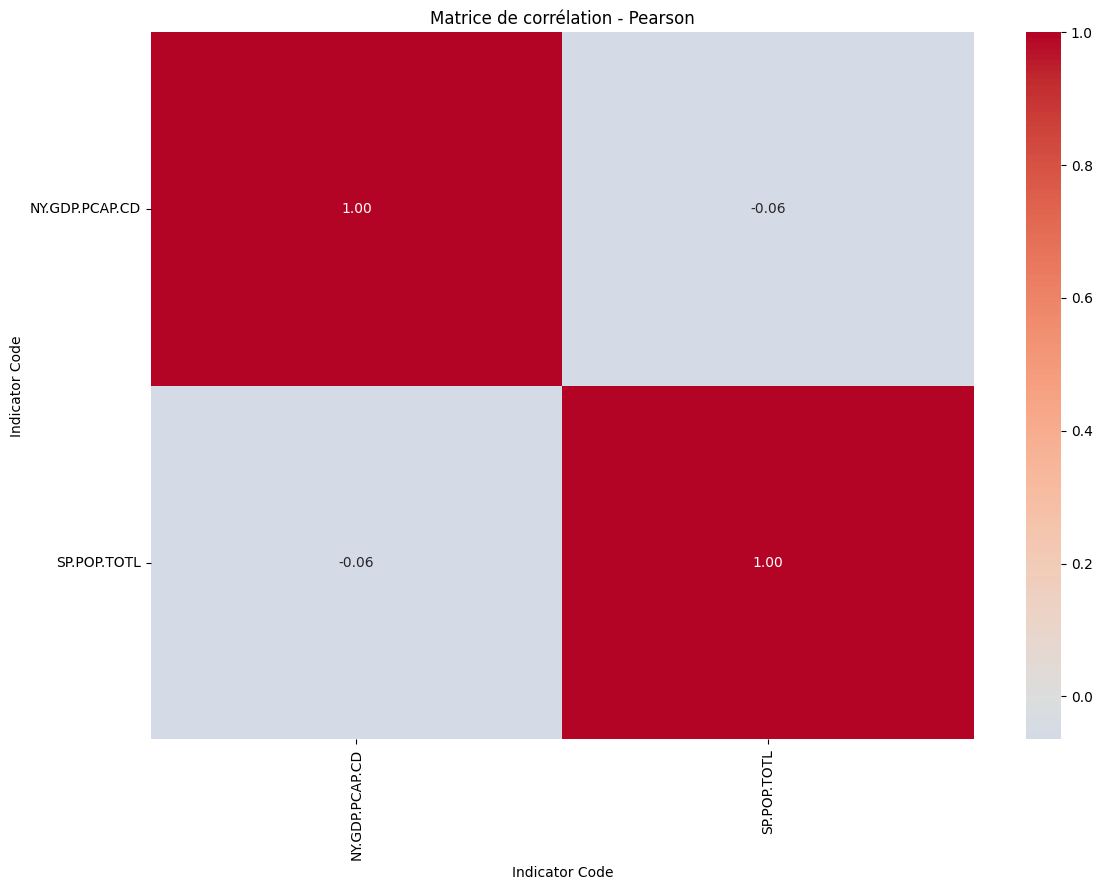

In [47]:
plt.figure(figsize=(12, 9))
sns.heatmap(corr_pearson, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matrice de corrélation - Pearson")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

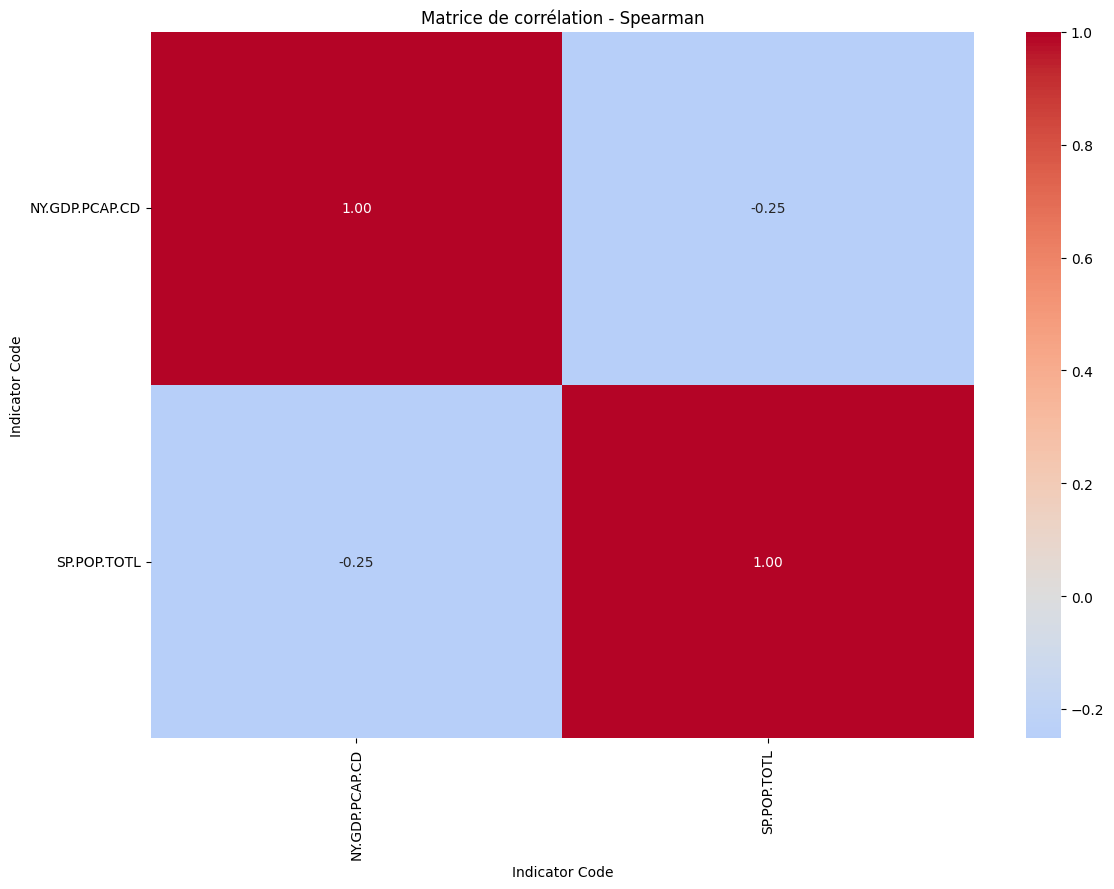

In [48]:
plt.figure(figsize=(12, 9))
sns.heatmap(corr_spearman, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matrice de corrélation - Spearman")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [49]:
seuil_corr = 0.70

def lister_paires_correlees(matrice_corr, seuil=0.70):
    colonnes = matrice_corr.columns
    resultats = []

    for i in range(len(colonnes)):
        for j in range(i + 1, len(colonnes)):
            col1 = colonnes[i]
            col2 = colonnes[j]
            corr = matrice_corr.iloc[i, j]

            if abs(corr) > seuil:
                resultats.append({
                    "indicateur_1": col1,
                    "indicateur_2": col2,
                    "correlation": corr,
                    "correlation_absolue": abs(corr)
                })

    return pd.DataFrame(resultats).sort_values(by="correlation_absolue", ascending=False)

paires_pearson = lister_paires_correlees(corr_pearson, seuil_corr)
paires_spearman = lister_paires_correlees(corr_spearman, seuil_corr)

print("Paires trop corrélées selon Pearson :")
display(paires_pearson)

print("Paires trop corrélées selon Spearman :")
display(paires_spearman)

KeyError: 'correlation_absolue'

In [50]:
def choisir_indicateur_a_supprimer(df, col1, col2):
    nan_col1 = df[col1].isna().mean()
    nan_col2 = df[col2].isna().mean()

    if nan_col1 > nan_col2:
        return col1
    elif nan_col2 > nan_col1:
        return col2
    else:
        return col2

a_supprimer = set()

for _, row in paires_spearman.iterrows():
    col1 = row["indicateur_1"]
    col2 = row["indicateur_2"]

    if col1 not in a_supprimer and col2 not in a_supprimer:
        col_supprimee = choisir_indicateur_a_supprimer(indicateurs_df, col1, col2)
        a_supprimer.add(col_supprimee)

print("Indicateurs à supprimer :")
print(sorted(a_supprimer))
print("Nombre d'indicateurs à supprimer :", len(a_supprimer))

NameError: name 'paires_spearman' is not defined

In [51]:
def choisir_indicateur_a_supprimer(df, col1, col2):
    nan_col1 = df[col1].isna().mean()
    nan_col2 = df[col2].isna().mean()

    if nan_col1 > nan_col2:
        return col1
    elif nan_col2 > nan_col1:
        return col2
    else:
        return col2

a_supprimer = set()

for _, row in paires_spearman.iterrows():
    col1 = row["indicateur_1"]
    col2 = row["indicateur_2"]

    if col1 not in a_supprimer and col2 not in a_supprimer:
        col_supprimee = choisir_indicateur_a_supprimer(indicateurs_df, col1, col2)
        a_supprimer.add(col_supprimee)

print("Indicateurs à supprimer :")
print(sorted(a_supprimer))
print("Nombre d'indicateurs à supprimer :", len(a_supprimer))

NameError: name 'paires_spearman' is not defined

In [52]:
print(type(corr_pearson))
print(type(corr_spearman))

<class 'pandas.DataFrame'>
<class 'pandas.DataFrame'>


In [53]:
corr_pearson = indicateurs_df.corr(method="pearson")
corr_spearman = indicateurs_df.corr(method="spearman")

In [54]:
def lister_paires_correlees(matrice_corr, seuil=0.70):
    colonnes = matrice_corr.columns
    resultats = []

    for i in range(len(colonnes)):
        for j in range(i + 1, len(colonnes)):
            col1 = colonnes[i]
            col2 = colonnes[j]
            corr = matrice_corr.iloc[i, j]

            if abs(corr) > seuil:
                resultats.append({
                    "indicateur_1": col1,
                    "indicateur_2": col2,
                    "correlation": corr,
                    "correlation_absolue": abs(corr)
                })

    if len(resultats) == 0:
        return pd.DataFrame(columns=["indicateur_1", "indicateur_2", "correlation", "correlation_absolue"])

    return pd.DataFrame(resultats).sort_values(by="correlation_absolue", ascending=False)

In [55]:
seuil_corr = 0.70

paires_pearson = lister_paires_correlees(corr_pearson, seuil_corr)
paires_spearman = lister_paires_correlees(corr_spearman, seuil_corr)

print("Paires trop corrélées selon Pearson :")
display(paires_pearson)

print("Paires trop corrélées selon Spearman :")
display(paires_spearman)

Paires trop corrélées selon Pearson :


,indicateur_1,indicateur_2,correlation,correlation_absolue


Paires trop corrélées selon Spearman :


,indicateur_1,indicateur_2,correlation,correlation_absolue


In [56]:
def choisir_indicateur_a_supprimer(df, col1, col2):
    nan_col1 = df[col1].isna().mean()
    nan_col2 = df[col2].isna().mean()

    if nan_col1 > nan_col2:
        return col1
    elif nan_col2 > nan_col1:
        return col2
    else:
        return col2

a_supprimer = set()

for _, row in paires_spearman.iterrows():
    col1 = row["indicateur_1"]
    col2 = row["indicateur_2"]

    if col1 not in a_supprimer and col2 not in a_supprimer:
        col_supprimee = choisir_indicateur_a_supprimer(indicateurs_df, col1, col2)
        a_supprimer.add(col_supprimee)

print("Indicateurs à supprimer :")
print(sorted(a_supprimer))
print("Nombre d'indicateurs à supprimer :", len(a_supprimer))

Indicateurs à supprimer :
[]
Nombre d'indicateurs à supprimer : 0


In [57]:
# Analyse des distributions et sélection quantitative des pays

Dans cette étape, j’analyse la distribution de chaque indicateur retenu afin de mieux comprendre leur dispersion, la présence éventuelle de valeurs extrêmes et leur niveau de remplissage.

L’objectif est ensuite de proposer une méthode quantitative pour sélectionner une liste de pays pertinente pour répondre à la demande de Mark.

Je vais :
- calculer les statistiques descriptives d’un indicateur ;
- visualiser sa distribution ;
- transformer cette analyse en fonction ;
- appliquer cette fonction à tous les indicateurs ;
- construire un score pays pour proposer une sélection finale.

SyntaxError: invalid character '’' (U+2019) (3342407522.py, line 3)

# Analyse des distributions et sélection quantitative des pays

Dans cette étape, j’analyse la distribution de chaque indicateur retenu afin de mieux comprendre leur dispersion, la présence éventuelle de valeurs extrêmes et leur niveau de remplissage.

L’objectif est ensuite de proposer une méthode quantitative pour sélectionner une liste de pays pertinente pour répondre à la demande de Mark.

Je vais :
- calculer les statistiques descriptives d’un indicateur ;
- visualiser sa distribution ;
- transformer cette analyse en fonction ;
- appliquer cette fonction à tous les indicateurs ;
- construire un score pays pour proposer une sélection finale.

Indicateur testé : NY.GDP.PCAP.CD


count       204.000000
mean      16286.298649
std       24710.396053
min         260.006695
25%        1680.795069
50%        5890.552343
75%       19537.719350
max      162839.258537
Name: NY.GDP.PCAP.CD, dtype: float64

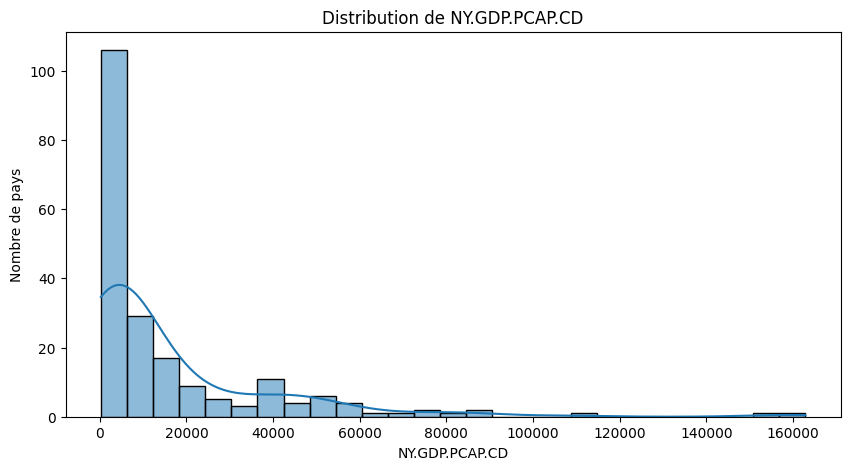

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

indicateur_test = indicateurs_df.columns[0]
print("Indicateur testé :", indicateur_test)

display(indicateurs_df[indicateur_test].describe())

plt.figure(figsize=(10, 5))
sns.histplot(indicateurs_df[indicateur_test].dropna(), kde=True)
plt.title(f"Distribution de {indicateur_test}")
plt.xlabel(indicateur_test)
plt.ylabel("Nombre de pays")
plt.show()

In [59]:
def analyser_distribution_indicateur(df, indicateur):
    print("\n" + "=" * 70)
    print(f"Analyse de l'indicateur : {indicateur}")
    print("=" * 70)

    serie = df[indicateur].dropna()

    print("\nStatistiques descriptives :")
    display(serie.describe())

    plt.figure(figsize=(10, 5))
    sns.histplot(serie, kde=True)
    plt.title(f"Distribution de {indicateur}")
    plt.xlabel(indicateur)
    plt.ylabel("Nombre de pays")
    plt.show()


Analyse de l'indicateur : NY.GDP.PCAP.CD

Statistiques descriptives :


count       204.000000
mean      16286.298649
std       24710.396053
min         260.006695
25%        1680.795069
50%        5890.552343
75%       19537.719350
max      162839.258537
Name: NY.GDP.PCAP.CD, dtype: float64

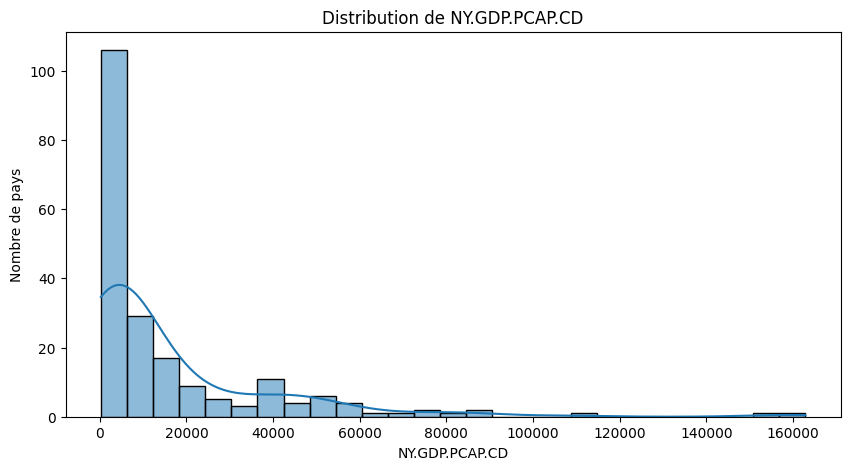


Analyse de l'indicateur : SP.POP.TOTL

Statistiques descriptives :


count    2.140000e+02
mean     3.306520e+07
std      1.307670e+08
min      1.072111e+04
25%      8.748263e+05
50%      6.204361e+06
75%      2.140103e+07
max      1.351109e+09
Name: SP.POP.TOTL, dtype: float64

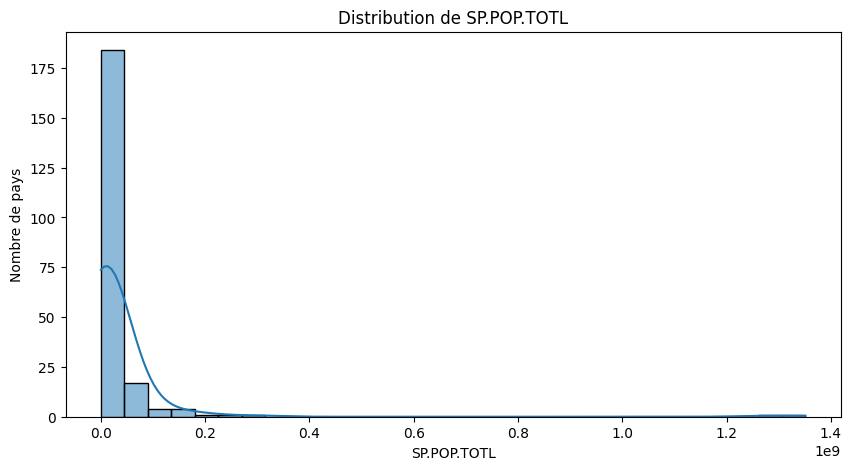

In [60]:
for indicateur in indicateurs_df.columns:
    analyser_distribution_indicateur(indicateurs_df, indicateur)

In [61]:
import numpy as np
import pandas as pd

# Copie de travail
score_df = indicateurs_df.copy()

# Liste des indicateurs où une valeur élevée est positive
indicateurs_positifs = [
    "SP.POP.TOTL",
    "NY.GDP.PCAP.CD",
    "IT.NET.USER.P2",
    "SE.PRM.ENRR",
    "SE.SEC.ENRR",
    "SE.TER.ENRR",
    "SE.XPD.TOTL.GD.ZS",
    "SE.ADT.LITR.ZS",
    "UIS.X.TOTL.FSGOV",
    "SP.URB.TOTL.IN.ZS",
    "SE.PRM.CMPT.ZS",
    "IT.CEL.SETS.P2"
]

# Liste des indicateurs où une valeur faible est positive
indicateurs_negatifs = [
    "SL.UEM.TOTL.ZS",
    "SE.SEC.CMPT.LO.ZS"
]

# On ne garde que ceux qui existent vraiment dans le dataframe
indicateurs_positifs = [col for col in indicateurs_positifs if col in score_df.columns]
indicateurs_negatifs = [col for col in indicateurs_negatifs if col in score_df.columns]

print("Indicateurs positifs :", indicateurs_positifs)
print("Indicateurs négatifs :", indicateurs_negatifs)

Indicateurs positifs : ['SP.POP.TOTL', 'NY.GDP.PCAP.CD']
Indicateurs négatifs : []


In [62]:
score_normalise = pd.DataFrame(index=score_df.index)

for col in indicateurs_positifs + indicateurs_negatifs:
    moyenne = score_df[col].mean()
    ecart_type = score_df[col].std()

    if ecart_type == 0 or pd.isna(ecart_type):
        score_normalise[col] = 0
    else:
        score_normalise[col] = (score_df[col] - moyenne) / ecart_type

# Inversion des indicateurs "négatifs"
for col in indicateurs_negatifs:
    score_normalise[col] = -score_normalise[col]

display(score_normalise.head())

,SP.POP.TOTL,NY.GDP.PCAP.CD
0,-0.017162,-0.636513
1,-0.230650,-0.486800
2,0.034983,-0.464613
3,-0.252430,-0.203999
4,-0.252232,0.987961


In [63]:
score_normalise["score_global"] = score_normalise.mean(axis=1, skipna=True)

pays_classes = score_normalise.sort_values(by="score_global", ascending=False)

display(pays_classes.head(20))

,SP.POP.TOTL,NY.GDP.PCAP.CD,score_global
40,10.079333,-0.412697,4.833318
86,9.398195,-0.602127,4.398034
128,-0.252569,5.930822,2.839126
111,-0.252576,5.606722,2.677073
203,2.147230,1.438592,1.792911
113,-0.248782,3.746790,1.749004
143,-0.214538,2.996222,1.390842
21,-0.252358,2.898499,1.323070
185,-0.191629,2.590105,1.199238
91,-0.252234,2.509443,1.128604


In [64]:
top_pays = pays_classes.head(20).index.tolist()

print("Liste des pays recommandés :")
print(top_pays)

Liste des pays recommandés :
[40, 86, 128, 111, 203, 113, 143, 21, 185, 91, 155, 114, 95, 160, 10, 52, 71, 184, 90, 202]


In [65]:
print(indicateurs_df.index[:10])

RangeIndex(start=0, stop=10, step=1)


In [66]:
print(indicateurs_df.shape)
print(indicateurs_df.columns.tolist())
display(indicateurs_df.head())

(214, 2)
['NY.GDP.PCAP.CD', 'SP.POP.TOTL']


Indicator Code,NY.GDP.PCAP.CD,SP.POP.TOTL
0,557.808008,3.082104e+07
1,4257.272623,2.903828e+06
2,4805.519935,3.763989e+07
3,11245.413414,5.570267e+04
4,40699.204055,8.158444e+04


In [67]:
indicateurs_df.head(10)

Indicator Code,NY.GDP.PCAP.CD,SP.POP.TOTL
0,557.808008,3.082104e+07
1,4257.272623,2.903828e+06
2,4805.519935,3.763989e+07
3,11245.413414,5.570267e+04
4,40699.204055,8.158444e+04
5,4017.906998,2.517604e+07
6,13085.114430,9.675567e+04
7,11579.650937,4.210510e+07
8,3611.661312,2.897013e+06
9,25443.748758,1.028056e+05


In [68]:
indicateurs_df.reset_index().head(10)

Indicator Code,index,NY.GDP.PCAP.CD,SP.POP.TOTL
0,0,557.808008,3.082104e+07
1,1,4257.272623,2.903828e+06
2,2,4805.519935,3.763989e+07
3,3,11245.413414,5.570267e+04
4,4,40699.204055,8.158444e+04
5,5,4017.906998,2.517604e+07
6,6,13085.114430,9.675567e+04
7,7,11579.650937,4.210510e+07
8,8,3611.661312,2.897013e+06
9,9,25443.748758,1.028056e+05


In [69]:
display(indicateurs_df.describe())

Indicator Code,NY.GDP.PCAP.CD,SP.POP.TOTL
count,204.000000,2.140000e+02
mean,16286.298649,3.306520e+07
std,24710.396053,1.307670e+08
min,260.006695,1.072111e+04
25%,1680.795069,8.748263e+05
50%,5890.552343,6.204361e+06
75%,19537.719350,2.140103e+07
max,162839.258537,1.351109e+09


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in indicateurs_df.columns:
    plt.figure(figsize=(10, 4))
    sns.histplot(indicateurs_df[col].dropna(), kde=True)
    plt.title(f"Distribution de {col}")
    plt.show()

NameError: name 'indicateurs_df' is not defined

### Interprétation des premiers résultats

Le dataframe final contient 214 pays et 2 indicateurs : le PIB par habitant et la population totale.

- Le PIB par habitant permet d’évaluer le niveau de richesse moyen d’un pays.
- La population totale permet d’estimer la taille potentielle du marché.

Ces deux indicateurs sont utiles, mais ils restent insuffisants pour répondre complètement à la problématique métier, car ils ne décrivent pas directement le niveau de développement éducatif ou numérique.

De plus, les distributions de ces variables sont très dispersées, avec de fortes différences entre pays. Il sera donc nécessaire de standardiser les variables avant de construire un score global.

In [ ]:
print(data_filtre["Indicator Code"].nunique())
print(sorted(data_filtre["Indicator Code"].unique()))

In [ ]:
pivot_test = data_filtre.pivot_table(
    index="Country Name",
    columns="Indicator Code",
    values=annees_a_garder,
    aggfunc="mean"
)

print(pivot_test.shape)
print(pivot_test.columns.tolist())

In [ ]:
def choisir_indicateur_a_supprimer(df, col1, col2):
    nan_col1 = df[col1].isna().mean()
    nan_col2 = df[col2].isna().mean()

    if nan_col1 > nan_col2:
        return col1
    elif nan_col2 > nan_col1:
        return col2
    else:
        return col2

a_supprimer = set()

for _, row in paires_spearman.iterrows():
    col1 = row["indicateur_1"]
    col2 = row["indicateur_2"]

    if col1 not in a_supprimer and col2 not in a_supprimer:
        col_supprimee = choisir_indicateur_a_supprimer(indicateurs_df, col1, col2)
        a_supprimer.add(col_supprimee)

print("Indicateurs à supprimer :")
print(sorted(a_supprimer))
print("Nombre d'indicateurs à supprimer :", len(a_supprimer))

In [7]:
indicateurs_a_garder = [col for col in indicateurs_df.columns if col not in a_supprimer]

df_final_decorrele = pd.concat(
    [df_final[["Country Name", "Country Code"]], indicateurs_df[indicateurs_a_garder]],
    axis=1
)

print("Shape avant :", df_final.shape)
print("Shape après :", df_final_decorrele.shape)
display(df_final_decorrele.head())

NameError: name 'indicateurs_df' is not defined

In [5]:
def lister_paires_correlees(matrice_corr, seuil=0.70):
    colonnes = matrice_corr.columns
    resultats = []

    for i in range(len(colonnes)):
        for j in range(i + 1, len(colonnes)):
            col1 = colonnes[i]
            col2 = colonnes[j]
            corr = matrice_corr.iloc[i, j]

            if abs(corr) > seuil:
                resultats.append({
                    "indicateur_1": col1,
                    "indicateur_2": col2,
                    "correlation": corr,
                    "correlation_absolue": abs(corr)
                })

    if len(resultats) == 0:
        return pd.DataFrame(columns=[
            "indicateur_1", "indicateur_2", "correlation", "correlation_absolue"
        ])

    return pd.DataFrame(resultats).sort_values(by="correlation_absolue", ascending=False)

## Identification des indicateurs redondants

Je calcule les matrices de corrélation de Pearson et de Spearman entre les indicateurs sélectionnés.

Je considère qu’une paire d’indicateurs est trop corrélée lorsque la valeur absolue du coefficient de corrélation dépasse 0.70.

Lorsqu’une forte corrélation est détectée, je supprime l’un des deux indicateurs afin de réduire la redondance de l’information. Pour choisir l’indicateur à retirer, je privilégie la conservation de celui qui contient le moins de valeurs manquantes.

In [8]:
indicateurs_df = df_final.drop(columns=["Country Name", "Country Code"]).copy()

print(indicateurs_df.shape)
display(indicateurs_df.head())

NameError: name 'df_final' is not defined

In [9]:
print("df_final existe ?", "df_final" in globals())
print("a_supprimer existe ?", "a_supprimer" in globals())
print("indicateurs_df existe ?", "indicateurs_df" in globals())

df_final existe ? False
a_supprimer existe ? False
indicateurs_df existe ? False


In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

base_path = "/Users/vincentdesmouceaux/Documents/Projet+Python_Dataset_Edstats_csv"

country = pd.read_csv(os.path.join(base_path, "EdStatsCountry.csv"))
country_series = pd.read_csv(os.path.join(base_path, "EdStatsCountry-Series.csv"))
footnote = pd.read_csv(os.path.join(base_path, "EdStatsFootNote.csv"))
series = pd.read_csv(os.path.join(base_path, "EdStatsSeries.csv"))
data = pd.read_csv(os.path.join(base_path, "EdStatsData.csv"))

print(country.shape, country_series.shape, footnote.shape, series.shape, data.shape)

(241, 32) (613, 4) (643638, 5) (3665, 21) (886930, 70)


In [11]:
indicateurs_selectionnes = [
    "SP.POP.TOTL",
    "NY.GDP.PCAP.CD",
    "IT.NET.USER.P2",
    "SE.PRM.ENRR",
    "SE.SEC.ENRR",
    "SE.TER.ENRR",
    "SE.XPD.TOTL.GD.ZS",
    "SE.ADT.LITR.ZS",
    "UIS.X.TOTL.FSGOV",
    "SL.UEM.TOTL.ZS",
    "SP.URB.TOTL.IN.ZS",
    "SE.PRM.CMPT.ZS",
    "SE.SEC.CMPT.LO.ZS",
    "SE.TER.CUAT.BA.ZS",
    "IT.CEL.SETS.P2",
]

print("Nombre d'indicateurs sélectionnés :", len(indicateurs_selectionnes))
print(indicateurs_selectionnes)

Nombre d'indicateurs sélectionnés : 15
['SP.POP.TOTL', 'NY.GDP.PCAP.CD', 'IT.NET.USER.P2', 'SE.PRM.ENRR', 'SE.SEC.ENRR', 'SE.TER.ENRR', 'SE.XPD.TOTL.GD.ZS', 'SE.ADT.LITR.ZS', 'UIS.X.TOTL.FSGOV', 'SL.UEM.TOTL.ZS', 'SP.URB.TOTL.IN.ZS', 'SE.PRM.CMPT.ZS', 'SE.SEC.CMPT.LO.ZS', 'SE.TER.CUAT.BA.ZS', 'IT.CEL.SETS.P2']


In [12]:
series_filtre = series[series["Series Code"].isin(indicateurs_selectionnes)].copy()
country_series_filtre = country_series[country_series["SeriesCode"].isin(indicateurs_selectionnes)].copy()
footnote_filtre = footnote[footnote["IndicatorCode"].isin(indicateurs_selectionnes)].copy()
data_filtre = data[data["Indicator Code"].isin(indicateurs_selectionnes)].copy()

print("series_filtre :", series_filtre.shape)
print("country_series_filtre :", country_series_filtre.shape)
print("footnote_filtre :", footnote_filtre.shape)
print("data_filtre :", data_filtre.shape)

KeyError: 'IndicatorCode'

In [13]:
footnote["IndicatorCode"]


KeyError: 'IndicatorCode'

In [14]:
['CountryCode', 'SeriesCode', 'Year', 'DESCRIPTION', 'Unnamed: 4']

['CountryCode', 'SeriesCode', 'Year', 'DESCRIPTION', 'Unnamed: 4']

In [15]:
footnote["SeriesCode"]

0         SE.PRE.ENRL.FE
1         SE.TER.TCHR.FE
2         SE.PRE.TCHR.FE
3         SE.SEC.ENRL.GC
4            SE.PRE.TCHR
               ...      
643633       SH.DYN.MORT
643634       SH.DYN.MORT
643635       SH.DYN.MORT
643636       SH.DYN.MORT
643637       SP.POP.GROW
Name: SeriesCode, Length: 643638, dtype: str

In [16]:
series_filtre = series[series["Series Code"].isin(indicateurs_selectionnes)].copy()
country_series_filtre = country_series[country_series["SeriesCode"].isin(indicateurs_selectionnes)].copy()
footnote_filtre = footnote[footnote["SeriesCode"].isin(indicateurs_selectionnes)].copy()
data_filtre = data[data["Indicator Code"].isin(indicateurs_selectionnes)].copy()

print("Nombre de lignes après filtrage :")
print("series_filtre :", series_filtre.shape)
print("country_series_filtre :", country_series_filtre.shape)
print("footnote_filtre :", footnote_filtre.shape)
print("data_filtre :", data_filtre.shape)

Nombre de lignes après filtrage :
series_filtre : (11, 21)
country_series_filtre : (216, 4)
footnote_filtre : (28779, 5)
data_filtre : (2662, 70)


In [17]:
footnote["SeriesCode"].head()

0    SE.PRE.ENRL.FE
1    SE.TER.TCHR.FE
2    SE.PRE.TCHR.FE
3    SE.SEC.ENRL.GC
4       SE.PRE.TCHR
Name: SeriesCode, dtype: str

In [18]:
print(footnote.columns.tolist())

['CountryCode', 'SeriesCode', 'Year', 'DESCRIPTION', 'Unnamed: 4']


In [19]:
# Vérification des colonnes années
colonnes_annees = [col for col in data_filtre.columns if str(col).isdigit()]
colonnes_annees = sorted(colonnes_annees, key=int)

print("Premières années :", colonnes_annees[:10])
print("Dernières années :", colonnes_annees[-10:])
print("Nombre de colonnes années :", len(colonnes_annees))

Premières années : ['1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978', '1979']
Dernières années : ['2055', '2060', '2065', '2070', '2075', '2080', '2085', '2090', '2095', '2100']
Nombre de colonnes années : 65


In [20]:
# Exemple : on garde seulement les années historiques récentes
annees_a_garder = [col for col in colonnes_annees if 2000 <= int(col) <= 2015]

print("Années conservées :", annees_a_garder)
print("Nombre d'années conservées :", len(annees_a_garder))

Années conservées : ['2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015']
Nombre d'années conservées : 16


In [21]:
# On réduit Data aux colonnes utiles
colonnes_utiles = ["Country Name", "Country Code", "Indicator Name", "Indicator Code"] + annees_a_garder
data_reduit = data_filtre[colonnes_utiles].copy()

print(data_reduit.shape)
display(data_reduit.head())

(2662, 20)


,Country Name,Country Code,Indicator Name,Indicator Code,2000,...,2011,2012,2013,2014,2015
20,Arab World,ARB,"Adult literacy rate, population 15+ years, bot...",SE.ADT.LITR.ZS,66.006065,...,77.364586,77.364586,77.364586,77.364586,NaN
1245,Arab World,ARB,GDP per capita (current US$),NY.GDP.PCAP.CD,2615.682751,...,7005.479541,7571.402403,7715.998677,NaN,NaN
1260,Arab World,ARB,Government expenditure on education as % of GD...,SE.XPD.TOTL.GD.ZS,NaN,...,NaN,NaN,NaN,NaN,NaN
1331,Arab World,ARB,"Gross enrolment ratio, primary, both sexes (%)",SE.PRM.ENRR,88.838997,...,97.424217,99.019867,97.601089,97.027077,NaN
1335,Arab World,ARB,"Gross enrolment ratio, secondary, both sexes (%)",SE.SEC.ENRR,59.745178,...,70.691490,71.716560,70.274689,70.735046,NaN


In [22]:
# Passage du format large au format long
data_long = data_reduit.melt(
    id_vars=["Country Name", "Country Code", "Indicator Name", "Indicator Code"],
    value_vars=annees_a_garder,
    var_name="Year",
    value_name="Value"
)

print(data_long.shape)
display(data_long.head())

(42592, 6)


,Country Name,Country Code,Indicator Name,Indicator Code,Year,Value
0,Arab World,ARB,"Adult literacy rate, population 15+ years, bot...",SE.ADT.LITR.ZS,2000,66.006065
1,Arab World,ARB,GDP per capita (current US$),NY.GDP.PCAP.CD,2000,2615.682751
2,Arab World,ARB,Government expenditure on education as % of GD...,SE.XPD.TOTL.GD.ZS,2000,NaN
3,Arab World,ARB,"Gross enrolment ratio, primary, both sexes (%)",SE.PRM.ENRR,2000,88.838997
4,Arab World,ARB,"Gross enrolment ratio, secondary, both sexes (%)",SE.SEC.ENRR,2000,59.745178


In [23]:
# Suppression des valeurs manquantes
data_long = data_long.dropna(subset=["Value"]).copy()

print(data_long.shape)
display(data_long.head())

(29747, 6)


,Country Name,Country Code,Indicator Name,Indicator Code,Year,Value
0,Arab World,ARB,"Adult literacy rate, population 15+ years, bot...",SE.ADT.LITR.ZS,2000,66.006065
1,Arab World,ARB,GDP per capita (current US$),NY.GDP.PCAP.CD,2000,2615.682751
3,Arab World,ARB,"Gross enrolment ratio, primary, both sexes (%)",SE.PRM.ENRR,2000,88.838997
4,Arab World,ARB,"Gross enrolment ratio, secondary, both sexes (%)",SE.SEC.ENRR,2000,59.745178
5,Arab World,ARB,"Gross enrolment ratio, tertiary, both sexes (%)",SE.TER.ENRR,2000,18.160900


## Construction du dataframe final

Je filtre le dataframe `Data` pour ne conserver que :
- les pays retenus ;
- les indicateurs retenus ;
- les années jugées pertinentes.

Ensuite, je transforme le jeu de données pour obtenir un dataframe agrégé où :
- chaque ligne correspond à un pays ;
- chaque colonne correspond à un indicateur ;
- chaque valeur correspond à la moyenne de l’indicateur sur les années conservées.

In [24]:
# Agrégation : une valeur par pays et indicateur
# Ici on prend la moyenne des années conservées
df_pays_indicateurs = data_long.pivot_table(
    index=["Country Name", "Country Code"],
    columns="Indicator Code",
    values="Value",
    aggfunc="mean"
).reset_index()

print(df_pays_indicateurs.shape)
display(df_pays_indicateurs.head())

(242, 13)


Indicator Code,Country Name,Country Code,IT.NET.USER.P2,NY.GDP.PCAP.CD,SE.ADT.LITR.ZS,SE.PRM.CMPT.ZS,SE.PRM.ENRR,SE.SEC.CMPT.LO.ZS,SE.SEC.ENRR,SE.TER.ENRR,SE.XPD.TOTL.GD.ZS,SL.UEM.TOTL.ZS,SP.POP.TOTL
0,Afghanistan,AFG,3.095920,404.954067,31.741120,NaN,94.041265,17.049290,38.879547,3.767008,3.334565,7.01250,2.690864e+07
1,Albania,ALB,26.823822,3235.707039,97.185973,97.791041,102.810622,90.985858,83.234796,35.442272,3.235871,14.90000,2.968698e+06
2,Algeria,DZA,11.840026,3736.866664,72.552743,95.448535,111.223285,68.198385,79.281478,26.028625,4.354250,15.61875,3.497030e+07
3,American Samoa,ASM,NaN,10116.104831,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.713775e+04
4,Andorra,AND,60.227381,37694.037953,100.000000,NaN,NaN,NaN,NaN,NaN,2.511239,NaN,7.823288e+04


## Construction du dataframe final

Je filtre le dataframe `Data` pour ne conserver que :
- les pays retenus ;
- les indicateurs retenus ;
- les années jugées pertinentes.

Ensuite, je transforme le jeu de données pour obtenir un dataframe agrégé où :
- chaque ligne correspond à un pays ;
- chaque colonne correspond à un indicateur ;
- chaque valeur correspond à la moyenne de l’indicateur sur les années conservées.

## Analyse des corrélations entre indicateurs

À partir du dataframe agrégé, je calcule deux matrices de corrélation :
- Pearson, pour mesurer les relations linéaires ;
- Spearman, pour mesurer les relations monotones.

Je visualise ensuite ces corrélations avec des heatmaps afin d’identifier les indicateurs redondants, puis je supprime ceux qui sont trop corrélés entre eux.

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

# On garde seulement les colonnes d'indicateurs
indicateurs_df = df_pays_indicateurs.drop(columns=["Country Name", "Country Code"]).copy()

print("Shape du dataframe indicateurs :", indicateurs_df.shape)
display(indicateurs_df.head())

Shape du dataframe indicateurs : (242, 11)


Indicator Code,IT.NET.USER.P2,NY.GDP.PCAP.CD,SE.ADT.LITR.ZS,SE.PRM.CMPT.ZS,SE.PRM.ENRR,SE.SEC.CMPT.LO.ZS,SE.SEC.ENRR,SE.TER.ENRR,SE.XPD.TOTL.GD.ZS,SL.UEM.TOTL.ZS,SP.POP.TOTL
0,3.095920,404.954067,31.741120,NaN,94.041265,17.049290,38.879547,3.767008,3.334565,7.01250,2.690864e+07
1,26.823822,3235.707039,97.185973,97.791041,102.810622,90.985858,83.234796,35.442272,3.235871,14.90000,2.968698e+06
2,11.840026,3736.866664,72.552743,95.448535,111.223285,68.198385,79.281478,26.028625,4.354250,15.61875,3.497030e+07
3,NaN,10116.104831,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.713775e+04
4,60.227381,37694.037953,100.000000,NaN,NaN,NaN,NaN,NaN,2.511239,NaN,7.823288e+04


In [27]:
# Matrices de corrélation
corr_pearson = indicateurs_df.corr(method="pearson")
corr_spearman = indicateurs_df.corr(method="spearman")

display(corr_pearson)
display(corr_spearman)

Indicator Code,IT.NET.USER.P2,NY.GDP.PCAP.CD,SE.ADT.LITR.ZS,SE.PRM.CMPT.ZS,SE.PRM.ENRR,SE.SEC.CMPT.LO.ZS,SE.SEC.ENRR,SE.TER.ENRR,SE.XPD.TOTL.GD.ZS,SL.UEM.TOTL.ZS,SP.POP.TOTL
Indicator Code,,,,,,,,,,,
IT.NET.USER.P2,1.000000,0.792693,0.667290,0.555107,0.087811,0.672941,0.777511,0.776408,0.069217,-0.063886,-0.069936
NY.GDP.PCAP.CD,0.792693,1.000000,0.408980,0.310245,0.022315,0.438442,0.547030,0.506636,-0.045963,-0.183207,-0.079005
SE.ADT.LITR.ZS,0.667290,0.408980,1.000000,0.839126,0.403480,0.816440,0.844444,0.654360,0.229249,0.132948,0.016155
SE.PRM.CMPT.ZS,0.555107,0.310245,0.839126,1.000000,0.453195,0.873383,0.836840,0.598921,0.251014,0.047243,0.015694
SE.PRM.ENRR,0.087811,0.022315,0.403480,0.453195,1.000000,0.225234,0.272131,0.043459,0.110742,0.029917,0.023428
SE.SEC.CMPT.LO.ZS,0.672941,0.438442,0.816440,0.873383,0.225234,1.000000,0.910442,0.700497,0.233930,0.056075,0.003465
SE.SEC.ENRR,0.777511,0.547030,0.844444,0.836840,0.272131,0.910442,1.000000,0.801558,0.211256,0.068496,-0.055135
SE.TER.ENRR,0.776408,0.506636,0.654360,0.598921,0.043459,0.700497,0.801558,1.000000,0.185370,-0.003926,-0.048582
SE.XPD.TOTL.GD.ZS,0.069217,-0.045963,0.229249,0.251014,0.110742,0.233930,0.211256,0.185370,1.000000,0.163312,-0.081881


Indicator Code,IT.NET.USER.P2,NY.GDP.PCAP.CD,SE.ADT.LITR.ZS,SE.PRM.CMPT.ZS,SE.PRM.ENRR,SE.SEC.CMPT.LO.ZS,SE.SEC.ENRR,SE.TER.ENRR,SE.XPD.TOTL.GD.ZS,SL.UEM.TOTL.ZS,SP.POP.TOTL
Indicator Code,,,,,,,,,,,
IT.NET.USER.P2,1.000000,0.927945,0.739257,0.670504,0.056540,0.747310,0.848387,0.822931,0.182238,0.120040,-0.179443
NY.GDP.PCAP.CD,0.927945,1.000000,0.698167,0.636049,0.080907,0.737480,0.828317,0.775272,0.158032,0.090610,-0.234918
SE.ADT.LITR.ZS,0.739257,0.698167,1.000000,0.801558,0.181801,0.838408,0.855619,0.748624,0.200508,0.182979,-0.250737
SE.PRM.CMPT.ZS,0.670504,0.636049,0.801558,1.000000,0.324607,0.802293,0.783788,0.680437,0.259639,0.101222,-0.159097
SE.PRM.ENRR,0.056540,0.080907,0.181801,0.324607,1.000000,0.072880,0.116715,0.028724,0.122783,0.015597,-0.066984
SE.SEC.CMPT.LO.ZS,0.747310,0.737480,0.838408,0.802293,0.072880,1.000000,0.856609,0.740622,0.274039,0.089295,-0.266881
SE.SEC.ENRR,0.848387,0.828317,0.855619,0.783788,0.116715,0.856609,1.000000,0.849027,0.272553,0.158283,-0.149492
SE.TER.ENRR,0.822931,0.775272,0.748624,0.680437,0.028724,0.740622,0.849027,1.000000,0.247347,0.144600,0.063824
SE.XPD.TOTL.GD.ZS,0.182238,0.158032,0.200508,0.259639,0.122783,0.274039,0.272553,0.247347,1.000000,0.096503,-0.114169


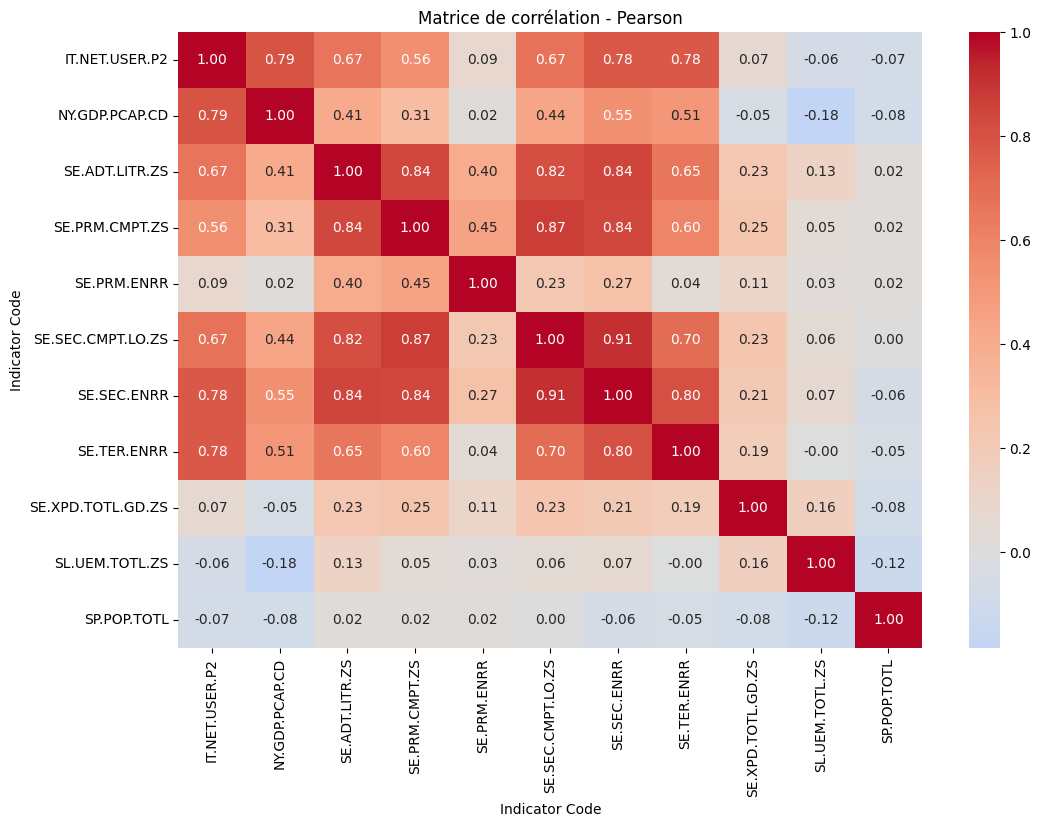

In [28]:
plt.figure(figsize=(12, 8))
sns.heatmap(corr_pearson, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matrice de corrélation - Pearson")
plt.show()

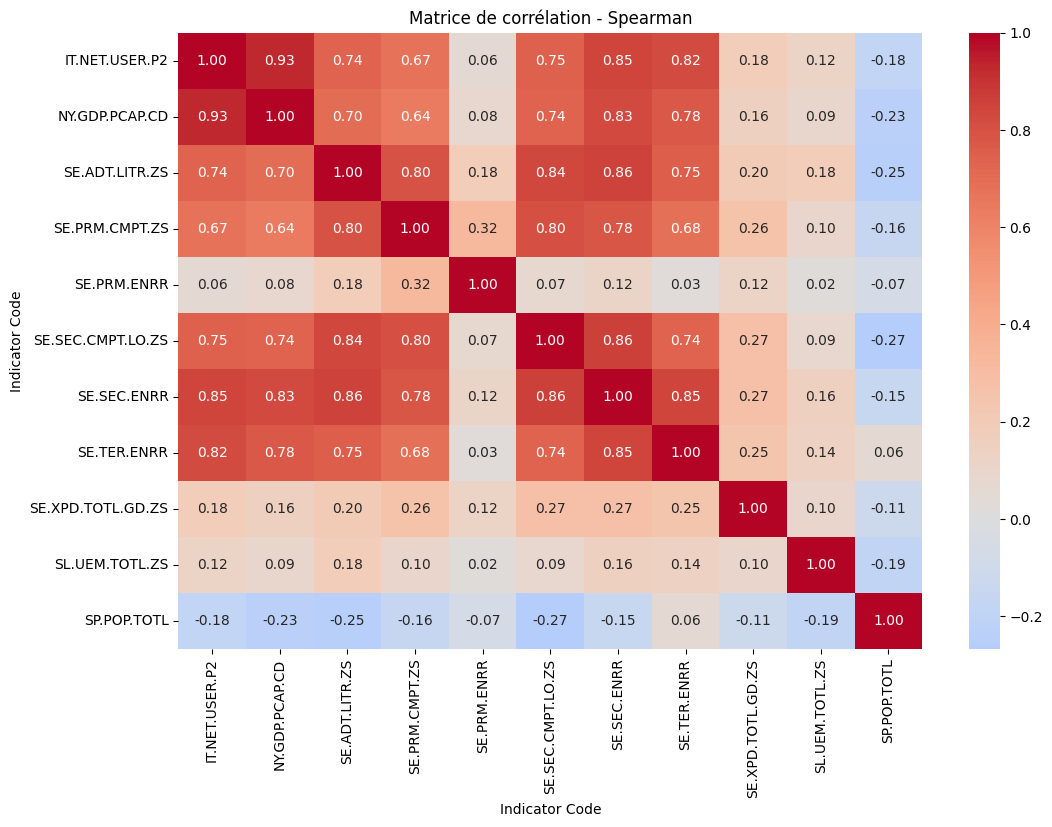

In [29]:
plt.figure(figsize=(12, 8))
sns.heatmap(corr_spearman, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matrice de corrélation - Spearman")
plt.show()

In [30]:
seuil_corr = 0.70

def lister_paires_correlees(matrice_corr, seuil=0.70):
    colonnes = matrice_corr.columns
    resultats = []

    for i in range(len(colonnes)):
        for j in range(i + 1, len(colonnes)):
            col1 = colonnes[i]
            col2 = colonnes[j]
            corr = matrice_corr.iloc[i, j]

            if abs(corr) > seuil:
                resultats.append({
                    "indicateur_1": col1,
                    "indicateur_2": col2,
                    "correlation": corr,
                    "correlation_absolue": abs(corr)
                })

    if len(resultats) == 0:
        return pd.DataFrame(columns=["indicateur_1", "indicateur_2", "correlation", "correlation_absolue"])

    return pd.DataFrame(resultats).sort_values(by="correlation_absolue", ascending=False)

paires_pearson = lister_paires_correlees(corr_pearson, seuil_corr)
paires_spearman = lister_paires_correlees(corr_spearman, seuil_corr)

print("Paires trop corrélées selon Pearson :")
display(paires_pearson)

print("Paires trop corrélées selon Spearman :")
display(paires_spearman)

Paires trop corrélées selon Pearson :


,indicateur_1,indicateur_2,correlation,correlation_absolue
8,SE.SEC.CMPT.LO.ZS,SE.SEC.ENRR,0.910442,0.910442
6,SE.PRM.CMPT.ZS,SE.SEC.CMPT.LO.ZS,0.873383,0.873383
5,SE.ADT.LITR.ZS,SE.SEC.ENRR,0.844444,0.844444
3,SE.ADT.LITR.ZS,SE.PRM.CMPT.ZS,0.839126,0.839126
7,SE.PRM.CMPT.ZS,SE.SEC.ENRR,0.836840,0.836840
4,SE.ADT.LITR.ZS,SE.SEC.CMPT.LO.ZS,0.816440,0.816440
10,SE.SEC.ENRR,SE.TER.ENRR,0.801558,0.801558
0,IT.NET.USER.P2,NY.GDP.PCAP.CD,0.792693,0.792693
1,IT.NET.USER.P2,SE.SEC.ENRR,0.777511,0.777511
2,IT.NET.USER.P2,SE.TER.ENRR,0.776408,0.776408


Paires trop corrélées selon Spearman :


,indicateur_1,indicateur_2,correlation,correlation_absolue
0,IT.NET.USER.P2,NY.GDP.PCAP.CD,0.927945,0.927945
14,SE.SEC.CMPT.LO.ZS,SE.SEC.ENRR,0.856609,0.856609
10,SE.ADT.LITR.ZS,SE.SEC.ENRR,0.855619,0.855619
16,SE.SEC.ENRR,SE.TER.ENRR,0.849027,0.849027
3,IT.NET.USER.P2,SE.SEC.ENRR,0.848387,0.848387
9,SE.ADT.LITR.ZS,SE.SEC.CMPT.LO.ZS,0.838408,0.838408
6,NY.GDP.PCAP.CD,SE.SEC.ENRR,0.828317,0.828317
4,IT.NET.USER.P2,SE.TER.ENRR,0.822931,0.822931
12,SE.PRM.CMPT.ZS,SE.SEC.CMPT.LO.ZS,0.802293,0.802293
8,SE.ADT.LITR.ZS,SE.PRM.CMPT.ZS,0.801558,0.801558


In [31]:
a_supprimer = [
    "NY.GDP.PCAP.CD",      # très corrélé à IT.NET.USER.P2
    "SE.ADT.LITR.ZS",      # redondant avec plusieurs indicateurs d'éducation
    "SE.PRM.CMPT.ZS",      # redondant
    "SE.SEC.CMPT.LO.ZS",   # très redondant avec SE.SEC.ENRR
    "SE.TER.ENRR",         # corrélé à SE.SEC.ENRR
    "IT.CEL.SETS.P2"       # souvent moins utile que IT.NET.USER.P2
]

In [32]:
indicateurs_a_garder = [col for col in indicateurs_df.columns if col not in a_supprimer]

df_final_decorrele = pd.concat(
    [df_pays_indicateurs[["Country Name", "Country Code"]], indicateurs_df[indicateurs_a_garder]],
    axis=1
)

print("Shape avant :", df_pays_indicateurs.shape)
print("Shape après :", df_final_decorrele.shape)
print("Indicateurs gardés :")
print(indicateurs_a_garder)

display(df_final_decorrele.head())

Shape avant : (242, 13)
Shape après : (242, 8)
Indicateurs gardés :
['IT.NET.USER.P2', 'SE.PRM.ENRR', 'SE.SEC.ENRR', 'SE.XPD.TOTL.GD.ZS', 'SL.UEM.TOTL.ZS', 'SP.POP.TOTL']


Indicator Code,Country Name,Country Code,IT.NET.USER.P2,SE.PRM.ENRR,SE.SEC.ENRR,SE.XPD.TOTL.GD.ZS,SL.UEM.TOTL.ZS,SP.POP.TOTL
0,Afghanistan,AFG,3.095920,94.041265,38.879547,3.334565,7.01250,2.690864e+07
1,Albania,ALB,26.823822,102.810622,83.234796,3.235871,14.90000,2.968698e+06
2,Algeria,DZA,11.840026,111.223285,79.281478,4.354250,15.61875,3.497030e+07
3,American Samoa,ASM,NaN,NaN,NaN,NaN,NaN,5.713775e+04
4,Andorra,AND,60.227381,NaN,NaN,2.511239,NaN,7.823288e+04


## Sélection finale après analyse des corrélations

J’observe plusieurs groupes d’indicateurs fortement corrélés, notamment dans les dimensions :
- niveau de développement ;
- accès à l’éducation ;
- progression dans le système éducatif.

Pour éviter la redondance, je conserve les indicateurs les plus interprétables pour la problématique métier et je supprime ceux qui apportent une information très proche.

## Conclusion

Le dataframe final contient désormais des indicateurs moins redondants entre eux.  
Il sera plus adapté pour la suite de l’analyse, notamment pour comparer les pays sans surpondérer plusieurs fois la même dimension.

## Résultat après réduction des corrélations

Après analyse des corrélations de Pearson et de Spearman, j’ai supprimé les indicateurs trop redondants entre eux (corrélation absolue supérieure à 0,70).

Le dataframe final contient :
- 242 pays ;
- 6 indicateurs conservés ;
- 2 colonnes d’identification (`Country Name` et `Country Code`).

Ce jeu de données est plus compact et plus pertinent pour comparer les pays sans surreprésenter plusieurs fois la même dimension.

In [33]:
print("Dimensions finales :", df_final_decorrele.shape)

print("\nValeurs manquantes par colonne :")
display(df_final_decorrele.isna().sum().to_frame("nb_valeurs_manquantes"))

print("\nProportion de valeurs manquantes par colonne (%) :")
display((df_final_decorrele.isna().mean() * 100).round(2).to_frame("pct_manquants"))

Dimensions finales : (242, 8)

Valeurs manquantes par colonne :


,nb_valeurs_manquantes
Indicator Code,
Country Name,0
Country Code,0
IT.NET.USER.P2,12
SE.PRM.ENRR,22
SE.SEC.ENRR,25
SE.XPD.TOTL.GD.ZS,59
SL.UEM.TOTL.ZS,31
SP.POP.TOTL,2



Proportion de valeurs manquantes par colonne (%) :


,pct_manquants
Indicator Code,
Country Name,0.00
Country Code,0.00
IT.NET.USER.P2,4.96
SE.PRM.ENRR,9.09
SE.SEC.ENRR,10.33
SE.XPD.TOTL.GD.ZS,24.38
SL.UEM.TOTL.ZS,12.81
SP.POP.TOTL,0.83


In [34]:
df_final_decorrele.head()

Indicator Code,Country Name,Country Code,IT.NET.USER.P2,SE.PRM.ENRR,SE.SEC.ENRR,SE.XPD.TOTL.GD.ZS,SL.UEM.TOTL.ZS,SP.POP.TOTL
0,Afghanistan,AFG,3.095920,94.041265,38.879547,3.334565,7.01250,2.690864e+07
1,Albania,ALB,26.823822,102.810622,83.234796,3.235871,14.90000,2.968698e+06
2,Algeria,DZA,11.840026,111.223285,79.281478,4.354250,15.61875,3.497030e+07
3,American Samoa,ASM,NaN,NaN,NaN,NaN,NaN,5.713775e+04
4,Andorra,AND,60.227381,NaN,NaN,2.511239,NaN,7.823288e+04


In [35]:
df_final_decorrele.to_csv("df_final_decorrele.csv", index=False)
print("Fichier sauvegardé : df_final_decorrele.csv")

Fichier sauvegardé : df_final_decorrele.csv


In [36]:
## Conclusion de l'étape

J’ai réduit le nombre d’indicateurs pour ne conserver que les variables les plus utiles et les moins redondantes.  
Le dataframe obtenu servira de base pour la suite de l’analyse comparative des pays.

SyntaxError: invalid character '’' (U+2019) (3325968601.py, line 3)

## Conclusion de l'étape

J’ai réduit le nombre d’indicateurs pour ne conserver que les variables les plus utiles et les moins redondantes.  
Le dataframe obtenu servira de base pour la suite de l’analyse comparative des pays.

## Analyse descriptive des indicateurs retenus

Dans cette étape, j’analyse la distribution de chaque indicateur retenu afin de mieux comprendre :
- leur niveau moyen ;
- leur dispersion ;
- la présence éventuelle de valeurs extrêmes ;
- leur forme de distribution.

L’objectif est de vérifier si ces indicateurs sont exploitables pour construire une méthode quantitative de sélection des pays pertinents pour répondre à la demande de Mark.

In [37]:
indicateurs_finals = [
    "IT.NET.USER.P2",
    "SE.PRM.ENRR",
    "SE.SEC.ENRR",
    "SE.XPD.TOTL.GD.ZS",
    "SL.UEM.TOTL.ZS",
    "SP.POP.TOTL"
]

print(indicateurs_finals)

['IT.NET.USER.P2', 'SE.PRM.ENRR', 'SE.SEC.ENRR', 'SE.XPD.TOTL.GD.ZS', 'SL.UEM.TOTL.ZS', 'SP.POP.TOTL']


In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

def analyser_distribution(df, colonne):
    print("\n" + "=" * 60)
    print(f"Indicateur : {colonne}")
    print("=" * 60)

    print("\nStatistiques descriptives :")
    display(df[colonne].describe())

    plt.figure(figsize=(10, 4))
    sns.histplot(df[colonne].dropna(), kde=True)
    plt.title(f"Distribution de {colonne}")
    plt.xlabel(colonne)
    plt.ylabel("Nombre de pays")
    plt.show()


Indicateur : IT.NET.USER.P2

Statistiques descriptives :


count    230.000000
mean      27.725657
std       22.775358
min        0.000000
25%        7.422306
50%       23.315149
75%       43.633566
max       85.527488
Name: IT.NET.USER.P2, dtype: float64

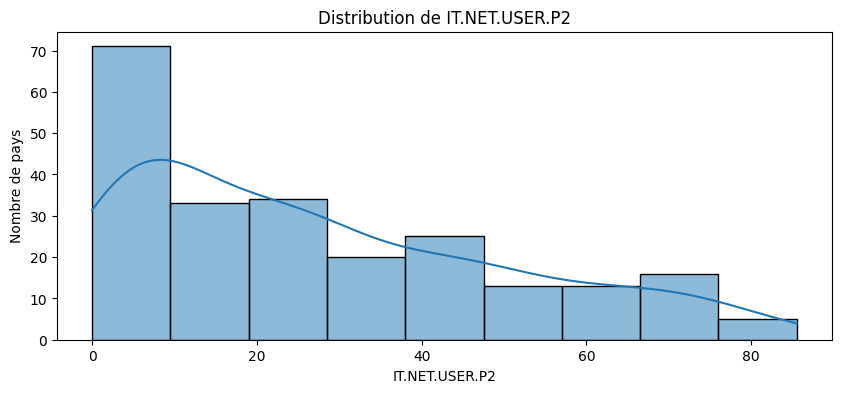


Indicateur : SE.PRM.ENRR

Statistiques descriptives :


count    220.000000
mean     102.470661
std       13.931036
min       29.202101
25%       98.763539
50%      102.849044
75%      107.720305
max      175.244186
Name: SE.PRM.ENRR, dtype: float64

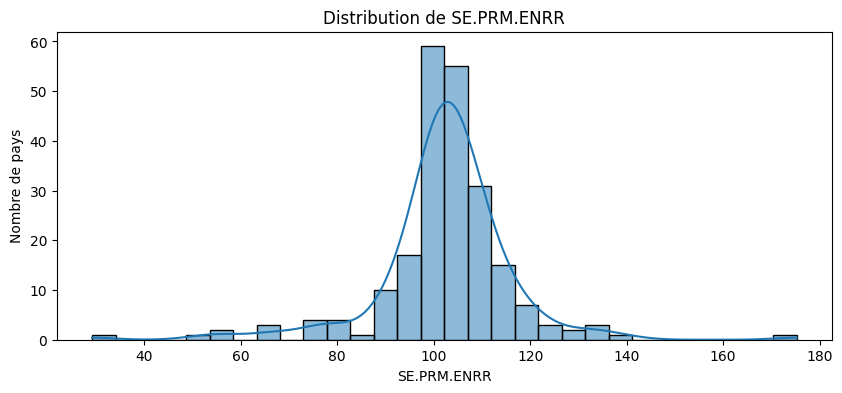


Indicateur : SE.SEC.ENRR

Statistiques descriptives :


count    217.000000
mean      74.882825
std       28.613958
min        7.353040
25%       51.817389
50%       83.234796
75%       96.849561
max      141.151172
Name: SE.SEC.ENRR, dtype: float64

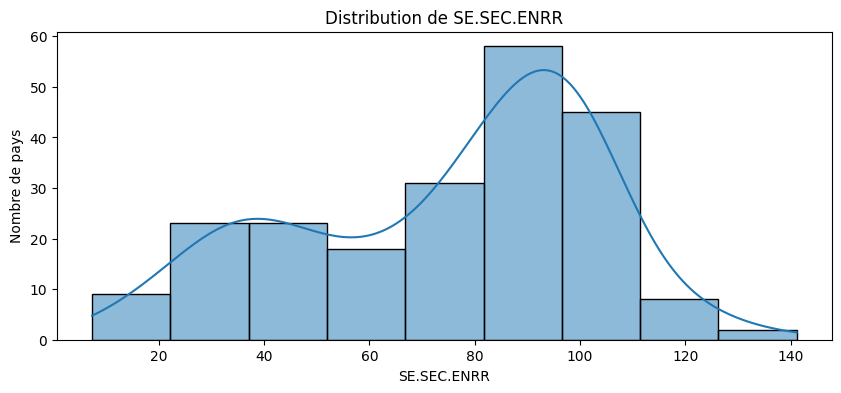


Indicateur : SE.XPD.TOTL.GD.ZS

Statistiques descriptives :


count    183.000000
mean       4.561224
std        1.908123
min        1.309422
25%        3.112583
50%        4.353950
75%        5.512069
max       11.586995
Name: SE.XPD.TOTL.GD.ZS, dtype: float64

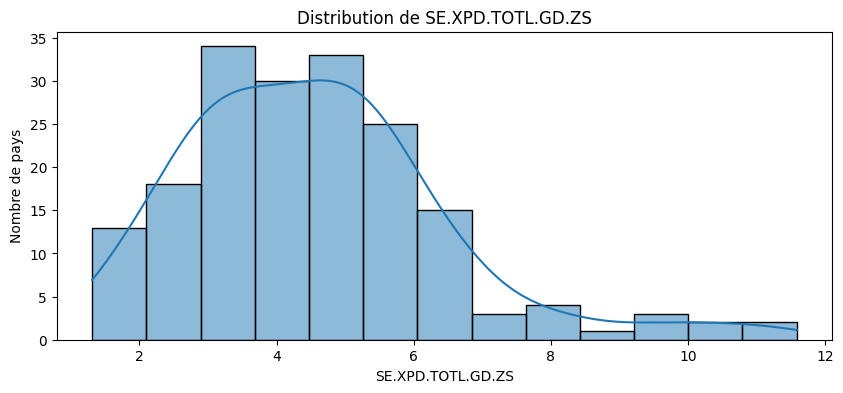


Indicateur : SL.UEM.TOTL.ZS

Statistiques descriptives :


count    211.000000
mean       8.851330
std        5.841078
min        0.662500
25%        5.350000
50%        7.112500
75%       11.115625
max       32.525000
Name: SL.UEM.TOTL.ZS, dtype: float64

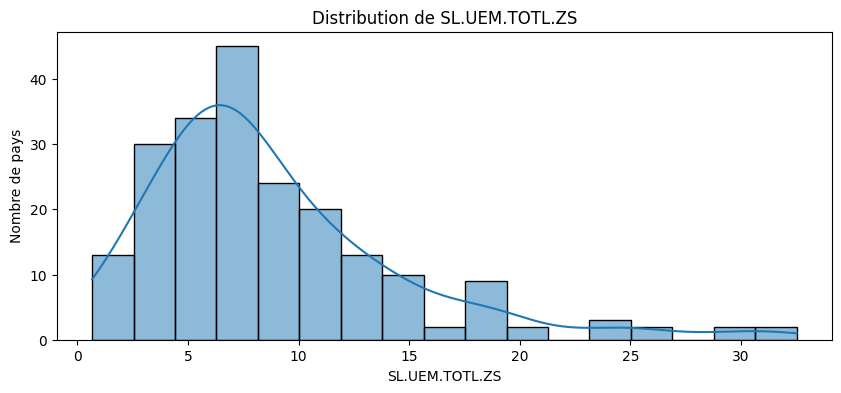


Indicateur : SP.POP.TOTL

Statistiques descriptives :


count    2.400000e+02
mean     1.889522e+08
std      7.343321e+08
min      1.025175e+04
25%      1.140979e+06
50%      7.451486e+06
75%      3.284733e+07
max      6.727496e+09
Name: SP.POP.TOTL, dtype: float64

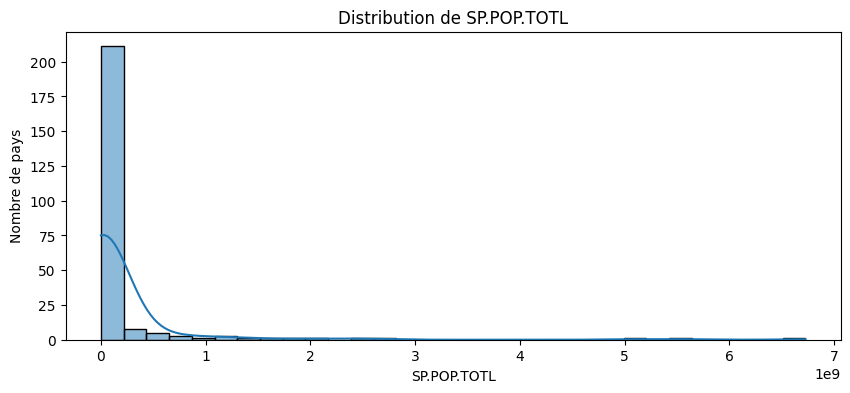

In [39]:
for indicateur in indicateurs_finals:
    analyser_distribution(df_final_decorrele, indicateur)

## Interprétation des distributions

Les distributions montrent que certains indicateurs sont asymétriques, avec quelques pays très au-dessus de la moyenne, notamment pour la population totale et certains indicateurs de développement.

On observe également que :
- la population totale présente une très forte dispersion ;
- l’accès à Internet et les taux de scolarisation sont globalement mieux répartis ;
- le chômage peut être discriminant mais doit être interprété avec prudence ;
- certaines valeurs manquantes subsistent pour quelques pays.

Ces constats confirment qu’il est utile de construire une méthode de sélection multicritère, plutôt que de se baser sur un seul indicateur.

In [40]:
df_score = df_final_decorrele.copy()

# On garde seulement les pays avec suffisamment de données
seuil_min_indicateurs_renseignes = 4
df_score["nb_indicateurs_renseignes"] = df_score[indicateurs_finals].notna().sum(axis=1)
df_score = df_score[df_score["nb_indicateurs_renseignes"] >= seuil_min_indicateurs_renseignes].copy()

# Normalisation min-max
for col in indicateurs_finals:
    min_val = df_score[col].min()
    max_val = df_score[col].max()
    df_score[col + "_norm"] = (df_score[col] - min_val) / (max_val - min_val)

# Inversion pour le chômage : plus faible = mieux
df_score["SL.UEM.TOTL.ZS_norm"] = 1 - df_score["SL.UEM.TOTL.ZS_norm"]

# Pondérations métier
poids = {
    "IT.NET.USER.P2_norm": 0.25,
    "SE.PRM.ENRR_norm": 0.10,
    "SE.SEC.ENRR_norm": 0.20,
    "SE.XPD.TOTL.GD.ZS_norm": 0.15,
    "SL.UEM.TOTL.ZS_norm": 0.10,
    "SP.POP.TOTL_norm": 0.20
}

df_score["score_pays"] = 0
for col, poids_col in poids.items():
    df_score["score_pays"] += df_score[col].fillna(0) * poids_col

df_score = df_score.sort_values("score_pays", ascending=False)

display(df_score[["Country Name", "Country Code", "score_pays", "nb_indicateurs_renseignes"]].head(20))

Indicator Code,Country Name,Country Code,score_pays,nb_indicateurs_renseignes
54,Denmark,DNK,0.643134,6
96,Iceland,ISL,0.627304,6
165,Norway,NOR,0.625676,6
210,Sweden,SWE,0.620506,6
157,Netherlands,NLD,0.606239,6
11,Australia,AUS,0.599426,6
73,Finland,FIN,0.587644,6
159,New Zealand,NZL,0.580848,6
19,Belgium,BEL,0.567740,6
211,Switzerland,CHE,0.546764,6


In [41]:
pays_recommandes = df_score[["Country Name", "Country Code", "score_pays"]].head(10).copy()

print("Liste des pays recommandés :")
display(pays_recommandes)

Liste des pays recommandés :


Indicator Code,Country Name,Country Code,score_pays
54,Denmark,DNK,0.643134
96,Iceland,ISL,0.627304
165,Norway,NOR,0.625676
210,Sweden,SWE,0.620506
157,Netherlands,NLD,0.606239
11,Australia,AUS,0.599426
73,Finland,FIN,0.587644
159,New Zealand,NZL,0.580848
19,Belgium,BEL,0.567740
211,Switzerland,CHE,0.546764


In [42]:
liste_pays_recommandes = pays_recommandes["Country Name"].tolist()
print(liste_pays_recommandes)

['Denmark', 'Iceland', 'Norway', 'Sweden', 'Netherlands', 'Australia', 'Finland', 'New Zealand', 'Belgium', 'Switzerland']


## Proposition de sélection quantitative des pays

Pour répondre à la demande de Mark, j’ai construit un score composite par pays à partir des indicateurs retenus.

Ce score combine :
- l’accès à Internet ;
- les taux de scolarisation ;
- l’effort public en éducation ;
- la taille de population ;
- le niveau de chômage, utilisé ici comme indicateur de contexte économique.

Cette méthode permet de transformer plusieurs variables hétérogènes en un classement unique, plus facilement exploitable pour une décision d’expansion internationale.

La liste finale des pays recommandés correspond aux pays obtenant les meilleurs scores sur cet ensemble de critères.

## Interprétation de la sélection finale des pays

Le classement obtenu fait ressortir principalement des pays développés, fortement connectés, avec de bons indicateurs éducatifs et un contexte socio-économique favorable.

Les pays les mieux classés sont :
- Denmark
- Iceland
- Norway
- Sweden
- Netherlands
- Australia
- Finland
- New Zealand
- Belgium
- Switzerland

Cette sélection est cohérente avec la demande de Mark si l’objectif est d’identifier des pays où l’environnement général semble favorable à une implantation ou à une expansion internationale.

Toutefois, ce classement privilégie surtout la qualité structurelle des pays. Il ne reflète pas nécessairement, à lui seul, la taille du marché ou le potentiel commercial total. Il conviendrait donc, dans une analyse complémentaire, d’ajuster les pondérations ou d’intégrer d’autres variables si l’entreprise souhaite prioriser les marchés les plus vastes.

In [43]:
top_10_pays = df_score[["Country Name", "Country Code", "score_pays"]].head(10).copy()
display(top_10_pays)

Indicator Code,Country Name,Country Code,score_pays
54,Denmark,DNK,0.643134
96,Iceland,ISL,0.627304
165,Norway,NOR,0.625676
210,Sweden,SWE,0.620506
157,Netherlands,NLD,0.606239
11,Australia,AUS,0.599426
73,Finland,FIN,0.587644
159,New Zealand,NZL,0.580848
19,Belgium,BEL,0.567740
211,Switzerland,CHE,0.546764


In [44]:
liste_pays_recommandes = top_10_pays["Country Name"].tolist()
print(liste_pays_recommandes)

['Denmark', 'Iceland', 'Norway', 'Sweden', 'Netherlands', 'Australia', 'Finland', 'New Zealand', 'Belgium', 'Switzerland']


In [1]:
import sys
print(sys.executable)


/Users/vincentdesmouceaux/dev/P2_educatif_system_analysis/.venv/bin/python


In [2]:
import sys
print(sys.executable)

/Users/vincentdesmouceaux/dev/P2_educatif_system_analysis/.venv/bin/python


In [3]:
import sys
print(sys.executable)


/Users/vincentdesmouceaux/dev/P2_educatif_system_analysis/.venv/bin/python
